# Ансамблевое моделирование и анализ интерпретируемости моделей

**Аналитическая структура**:
1. Разработка ансамблевых моделей с использованием четырех промышленных алгоритмов: Random Forest, XGBoost, LightGBM и CatBoost
2. Систематическая оптимизация гиперпараметров с применением трех различных методологий: полного перебора (grid search), случайного поиска (randomized search) и байесовской оптимизации
3. Глобальная интерпретация модели через несколько комплементарных техник, включая встроенную важность признаков, перестановочную важность и значения SHAP
4. Локальная интерпретация предсказаний с использованием каскадного анализа SHAP и LIME для понимания драйверов индивидуальных предсказаний


# 1. Импорт библиотек и настройка окружения


In [1]:
import time
import warnings

import catboost
import lightgbm as lgb
import lime
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)
from xgboost import XGBRegressor

from eda_util import set_global_seed

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

random_state = 42
set_global_seed(random_state)

print("Python packages versions:")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")
print(f"CatBoost: {catboost.__version__}")
print(f"SHAP: {shap.__version__}")
print(f"Optuna: {optuna.__version__}")
print(f"Random state: {random_state}")

Python packages versions:
XGBoost: 3.0.5
LightGBM: 4.6.0
CatBoost: 1.2.8
SHAP: 0.49.1
Optuna: 4.6.0
Random state: 42


# 2. Загрузка данных и baseline контекст


In [2]:
# Загружаем данные
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

X_train = train.drop("Stream", axis=1)
y_train = train["Stream"]
X_test = test.drop("Stream", axis=1)
y_test = test["Stream"]

# Преобразуем Album_type в categorical тип
X_train["Album_type"] = X_train["Album_type"].astype("category")
X_test["Album_type"] = X_test["Album_type"].astype("category")

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")
print(f"\nFeatures: {list(X_train.columns)}")
print(f"Album_type dtype: {X_train['Album_type'].dtype}")
categories = X_train["Album_type"].cat.categories.tolist()
print(f"Album_type categories: {categories}")
print("\nTarget statistics:")
print(f"  Mean: {y_train.mean() / 1e6:.2f} млн")
print(f"  Median: {y_train.median() / 1e6:.2f} млн")
print(f"  Std: {y_train.std() / 1e6:.2f} млн")

Train shape: (14086, 12), (14086,)
Test shape: (6037, 12), (6037,)

Features: ['Album_type', 'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms']
Album_type dtype: category
Album_type categories: ['album', 'compilation', 'single']

Target statistics:
  Mean: 135.74 млн
  Median: 49.68 млн
  Std: 242.43 млн


### Установление эталонной производительности

Предшествующий анализ установил базовую предсказательную производительность с использованием линейных моделей. Сравнительная производительность альтернативных методологий обеспечивает контекст для оценки эффективности ансамблевых моделей:

| Конфигурация модели | RMSE (млн) | MAE (млн) | Улучшение vs наивная baseline |
|---------------------|------------|-----------|-------------------------------|
| Dummy (медиана) | 262.653 | 116.535 | reference |
| Линейная регрессия | 242.659 | 138.518 | 7.6% |
| Ridge (α=30) | 242.661 | 138.501 | 7.6% |
| **Polynomial + Linear** | **241.144** | **137.130** | **8.2%** |
| Polynomial + Ridge (α=30) | 241.144 | 137.119 | 8.2% |
| Polynomial + Lasso (α=30) | 241.144 | 137.130 | 8.2% |
| Polynomial + ElasticNet (α=30) | 246.056 | 140.076 | 6.3% |

Текущий эталон производительности составляет 241.144 млн RMSE, достигнутый через полиномиальную инженерию признаков в комбинации с линейной регрессией. Это представляет улучшение на 8.2% по сравнению с наивным базовым предсказанием и устанавливает минимальный приемлемый порог производительности для ансамблевых подходов.


### Методология предобработки данных

Все модели используют стандартизованный пайплайн предобработки для обеспечения сопоставимости между методологиями и поддержания консистентности с предшествующим базовым анализом:

**Числовые признаки** (исключая Duration_ms): Стандартизация через StandardScaler для достижения нулевого среднего и единичной дисперсии, обеспечивая стабильность сходимости и позволяя прямую интерпретацию коэффициентов для признаков с различными естественными масштабами.

**Duration_ms**: Двухэтапная трансформация, комбинирующая логарифмическое масштабирование (log1p) с последующей нормализацией RobustScaler. Этот подход адресует выраженное правостороннее смещение распределения признака, смягчая влияние экстремальных выбросов при сохранении относительных отношений порядка.

**Album_type**: One-hot кодирование для преобразования трехуровневой категориальной переменной (album, compilation, single) в бинарные индикаторные признаки, избегая введения искусственных предположений об ординальности.

**Техническое обоснование**: Несмотря на то, что древовидные ансамблевые методы демонстрируют присущую инвариантность к монотонным трансформациям признаков и теоретически требуют минимальной предобработки, поддержание стандартизованного масштабирования служит двум стратегическим целям. Во-первых, оно обеспечивает методологическую консистентность с установленными базовыми моделями, позволяя прямую атрибуцию производительности. Во-вторых, оно улучшает стабильность градиентной оптимизации во время настройки гиперпараметров.

In [3]:
# Проверка категориального типа и распределения
print(f"Album_type dtype: {X_train['Album_type'].dtype}")
categories = X_train["Album_type"].cat.categories.tolist()
print(f"Album_type categories: {categories}")
print("\nValue counts in train:")
print(X_train["Album_type"].value_counts())
print("\nValue counts in test:")
print(X_test["Album_type"].value_counts())

Album_type dtype: category
Album_type categories: ['album', 'compilation', 'single']

Value counts in train:
Album_type
album          10155
single          3419
compilation      512
Name: count, dtype: int64

Value counts in test:
Album_type
album          4386
single         1430
compilation     221
Name: count, dtype: int64


In [4]:
def build_preprocessor():
    num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
        ["Duration_ms"]
    )
    cat_cols = ["Album_type"]

    categorical_preprocessing = Pipeline(
        [
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    numeric_preprocessing = Pipeline(
        [
            ("scaler", StandardScaler()),
        ]
    )

    duration_preprocessing = Pipeline(
        [
            (
                "log1p",
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
            ),
            ("scale", RobustScaler()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_preprocessing, num_cols),
            ("cat", categorical_preprocessing, cat_cols),
            ("duration", duration_preprocessing, ["Duration_ms"]),
        ],
        remainder="drop",
    )


preprocessing = build_preprocessor()
print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


# 3. Первичная оценка ансамблевых моделей с конфигурациями по умолчанию

Перед реализацией систематической оптимизации гиперпараметров мы устанавливаем базовую производительность ансамблей, используя конфигурации алгоритмов по умолчанию. Эта первичная оценка служит двум аналитическим целям: во-первых, она количественно определяет прирост производительности, достижимый через ансамблевые методы без затрат на настройку; во-вторых, она идентифицирует, какие алгоритмы демонстрируют превосходную производительность «из коробки» для данной конкретной задачи предсказания.


### 3.1 Базовый Random Forest

Random Forest представляет методологию бэггинга, которая конструирует множественные деревья решений, обученные на бутстрепированных выборках данных со случайным выбором подмножества признаков в каждой точке разделения. Этот механизм двойной рандомизации снижает дисперсию предсказаний при поддержании низкого смещения, делая Random Forest особенно эффективным для регрессионных задач с высокой дисперсией.


In [5]:
start_time = time.time()

rf_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor()),
        (
            "regressor",
            RandomForestRegressor(random_state=random_state, n_jobs=-1),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_time = time.time() - start_time
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (default parameters):")
print(f"  RMSE: {rf_rmse / 1e6:.3f} млн")
print(f"  MAE: {rf_mae / 1e6:.3f} млн")
print(f"  Training time: {rf_time:.2f}s")
print("\nImprovement over baseline (RMSE 241.144 млн):")
print(f"  {((241.144e6 - rf_rmse) / 241.144e6 * 100):.2f}%")

Random Forest (default parameters):
  RMSE: 222.634 млн
  MAE: 131.934 млн
  Training time: 1.37s

Improvement over baseline (RMSE 241.144 млн):
  7.68%


**Анализ производительности**: Random Forest достигает RMSE 222.634 млн, представляя улучшение на 7.68% по сравнению с эталоном полиномиальной регрессии (241.144 млн). Это составляет наиболее сильный прирост производительности конфигурации по умолчанию среди всех оцененных ансамблевых методов, с обучением, завершенным за 1.70 секунд, и MAE 131.934 млн, демонстрирующим робастную точность предсказания по всему распределению ошибок.

**Декомпозиция сравнительного преимущества**: Random Forest демонстрирует превосходную производительность «из коробки» относительно альтернатив градиентного бустинга, превосходя XGBoost на 10.0 млн RMSE (4.3%), LightGBM на 8.8 млн (3.8%), и CatBoost на 9.3 млн (4.0%). Этот дифференциал производительности может быть атрибутирован трем алгоритмическим характеристикам, особенно хорошо подходящим для задачи предсказания прослушиваний.

Во-первых, конфигурация неограниченной глубины деревьев Random Forest по умолчанию обеспечивает всестороннее разбиение данных по сравнению с неглубокими деревьями, типичными для умолчаний градиентного бустинга (глубина 6-8). Эта способность к сложным разделениям оказывается преимуществом, учитывая многомерное пространство аудио-признаков и экстремальный диапазон целевой переменной, охватывающий шесть порядков величины.

Во-вторых, механизм бэггинга, присущий Random Forest, демонстрирует особую эффективность для регрессионных проблем с высокой дисперсией. Усредняя предсказания от независимо обученных деревьев, построенных на бутстрепированных выборках, ансамбль достигает снижения дисперсии без введения последовательного накопления ошибок, характерного для подходов бустинга. Учитывая существенную дисперсию в производительности потоков (стандартное отклонение 242.43 млн), эта независимая стратегия агрегации оказывается более робастной, чем итеративная коррекция остатков.

В-третьих, несмотря на использование неограниченной глубины деревьев, агрегация ансамбля предотвращает переобучение, что подтверждается сильной генерализацией на тестовом наборе. Декорреляция, достигнутая через бутстреп-выборку и случайный выбор признаков в каждом разделении, создает разнообразие среди составляющих деревьев, обеспечивая точные предсказания.


### 3.2 Базовый XGBoost

XGBoost (Extreme Gradient Boosting) реализует оптимизированный фреймворк градиентного бустинга, который конструирует ансамбль через последовательное добавление деревьев, где каждое дерево обучается для коррекции остаточных ошибок своих предшественников.

In [6]:
start_time = time.time()

xgb_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor()),
        ("regressor", XGBRegressor(random_state=random_state, n_jobs=-1)),
    ]
)

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

xgb_time = time.time() - start_time
xgb_rmse = root_mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost (default parameters):")
print(f"  RMSE: {xgb_rmse / 1e6:.3f} млн")
print(f"  MAE: {xgb_mae / 1e6:.3f} млн")
print(f"  Training time: {xgb_time:.2f}s")
print("\nImprovement over baseline (RMSE 241.144 млн):")
print(f"  {((241.144e6 - xgb_rmse) / 241.144e6 * 100):.2f}%")

XGBoost (default parameters):
  RMSE: 232.671 млн
  MAE: 137.128 млн
  Training time: 0.32s

Improvement over baseline (RMSE 241.144 млн):
  3.51%


**Анализ производительности**: XGBoost достигает RMSE 232.671 млн, представляя улучшение на 3.51% по сравнению с полиномиальным эталоном, но отставая от Random Forest на 10.0 млн RMSE (дифференциал 4.3%). Обучение завершается за 0.28 секунд, приблизительно в шесть раз быстрее, чем Random Forest, в то время как MAE 137.128 млн указывает на несколько повышенные абсолютные ошибки по сравнению с 131.934 млн у Random Forest.

**Ограничения конфигурации по умолчанию**: Недостаточная производительность XGBoost относительно Random Forest с гиперпараметрами по умолчанию заслуживает детального исследования, так как это контрастирует с типичным конкурентным позиционированием алгоритма. Три конфигурационные характеристики вносят вклад в этот результат.

Максимальная глубина дерева по умолчанию 6 представляет консервативный выбор, предназначенный для предотвращения переобучения в типичных приложениях. Однако для данной специфической задачи предсказания, характеризуемой сложными взаимодействиями аудио-признаков и экстремальным диапазоном целевой переменной (охватывающим три порядка величины от тысяч до миллиардов), это ограничение глубины может недостаточно захватывать лежащие в основе нелинейные связи. Неограниченная глубина Random Forest обеспечивает более детальное разбиение данных, предоставляя преимущество в точности несмотря на повышенный риск переобучения.

Learning rate по умолчанию 0.3 представляет агрессивный размер шага в оптимизации градиентного спуска. Хотя это ускоряет сходимость во время обучения, это увеличивает риск перескакивания локальных оптимумов в ландшафте функции потерь. Random Forest, оперирующий без параметра learning rate через прямое усреднение, избегает этого компромисса между скоростью сходимости и точностью оптимизации.

Наконец, последовательная природа градиентного бустинга вводит потенциал для накопления ошибок через итерации. Когда индивидуальные деревья делают систематические ошибки на сложных примерах, последующие деревья наследуют эти смещения. Независимая конструкция деревьев Random Forest обеспечивает присущую защиту от этого, предлагая большую робастность, когда дисперсия целевой переменной высока.

**Выводы**: Существенный разрыв между производительностью XGBoost по умолчанию и Random Forest предполагает значительную возможность для улучшения через оптимизацию гиперпараметров. Ожидается, что систематическая настройка параметров глубины дерева и learning rate сократит этот дифференциал производительности, потенциально позволяя XGBoost сравняться или превзойти точность Random Forest при поддержании вычислительных преимуществ.


### 3.3 Базовый LightGBM

LightGBM (Light Gradient Boosting Machine) представляет реализацию градиентного бустинга от Microsoft, оптимизированную для вычислительной эффективности с крупномасштабными датасетами. Алгоритм использует рост дерева по листьям (leaf-wise) вместо поуровневого расширения (level-wise).


In [7]:
start_time = time.time()

lgbm_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor()),
        (
            "regressor",
            LGBMRegressor(random_state=random_state, n_jobs=-1, verbose=-1),
        ),
    ]
)

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

lgbm_time = time.time() - start_time
lgbm_rmse = root_mean_squared_error(y_test, y_pred_lgbm)
lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)

print("LightGBM (default parameters):")
print(f"  RMSE: {lgbm_rmse / 1e6:.3f} млн")
print(f"  MAE: {lgbm_mae / 1e6:.3f} млн")
print(f"  Training time: {lgbm_time:.2f}s")
print("\nImprovement over baseline (RMSE 241.144 млн):")
print(f"  {((241.144e6 - lgbm_rmse) / 241.144e6 * 100):.2f}%")

LightGBM (default parameters):
  RMSE: 231.447 млн
  MAE: 131.582 млн
  Training time: 0.72s

Improvement over baseline (RMSE 241.144 млн):
  4.02%


**Анализ производительности**: LightGBM достигает RMSE 231.447 млн, представляя вторую по силе производительность конфигурации по умолчанию с улучшением на 4.02% по сравнению с полиномиальным эталоном. Это позиционирует LightGBM впереди XGBoost (3.51%), хотя отставая от Random Forest (7.68%). Обучение завершается за 0.69 секунд, предлагая вычислительную эффективность между XGBoost и Random Forest. Примечательно, что MAE 131.582 млн близко аппроксимирует 131.934 млн у Random Forest, указывая на сопоставимую робастную оценку по всему распределению ошибок.

**Алгоритмические преимущества**: Превосходная производительность LightGBM относительно XGBoost, несмотря на то что оба используют фреймворки градиентного бустинга, отражает две благоприятные конструктивные характеристики.

Стратегия роста дерева по листьям (leaf-wise), используемая LightGBM, селективно расширяет листовой узел дерева, который обеспечивает максимальное снижение потерь, контрастируя с поуровневым подходом XGBoost (level-wise), который симметрично растит все листья на каждом уровне глубины.

Learning rate по умолчанию 0.1 в LightGBM обеспечивает более консервативные шаги градиентного спуска по сравнению с 0.3 у XGBoost, снижая риск нестабильности оптимизации. Эта трехкратная разница в размере шага обеспечивает более плавную сходимость при поддержании достаточной скорости обучения, балансируя эффективность тренировки с точностью предсказания.

**Выводы**: Среди реализаций градиентного бустинга LightGBM демонстрирует оптимальную конфигурацию по умолчанию, превосходя XGBoost на 1.2 млн RMSE (0.5%) и CatBoost на 0.5 млн (0.2%).
Учитывая уже конкурентную производительность по умолчанию, ожидается, что оптимизация гиперпараметров принесет умеренные инкрементальные приросты в диапазоне 2-3%, контрастируя с большим потенциалом оптимизации, идентифицированным для XGBoost.


### 3.4 Базовый CatBoost

CatBoost (Categorical Boosting) представляет реализацию градиентного бустинга от Yandex, отличающуюся специализированной обработкой категориальных переменных и симметричным конструированием деревьев.


In [8]:
start_time = time.time()

catboost_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor()),
        ("regressor", CatBoostRegressor(random_state=random_state, verbose=0)),
    ]
)

catboost_pipeline.fit(X_train, y_train)
y_pred_catboost = catboost_pipeline.predict(X_test)

catboost_time = time.time() - start_time
catboost_rmse = root_mean_squared_error(y_test, y_pred_catboost)
catboost_mae = mean_absolute_error(y_test, y_pred_catboost)

print("CatBoost (default parameters, with OneHotEncoder):")
print(f"  RMSE: {catboost_rmse / 1e6:.3f} млн")
print(f"  MAE: {catboost_mae / 1e6:.3f} млн")
print(f"  Training time: {catboost_time:.2f}s")
print("\nImprovement over baseline (RMSE 241.144 млн):")
print(f"  {((241.144e6 - catboost_rmse) / 241.144e6 * 100):.2f}%")

CatBoost (default parameters, with OneHotEncoder):
  RMSE: 231.976 млн
  MAE: 134.121 млн
  Training time: 1.43s

Improvement over baseline (RMSE 241.144 млн):
  3.80%


### 3.4.1 CatBoost с нативной обработкой категориальных признаков

Проверим особенность CatBoost обрабатывать категориальные признаки напрямую без OneHotEncoding. CatBoost использует ordered target statistics для категориальных признаков, что может быть более эффективно, чем OHE.


In [9]:
def build_preprocessor_with_cat():
    num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
        ["Duration_ms"]
    )

    numeric_preprocessing = Pipeline(
        [
            ("scaler", StandardScaler()),
        ]
    )

    duration_preprocessing = Pipeline(
        [
            (
                "log1p",
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
            ),
            ("scale", RobustScaler()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_preprocessing, num_cols),
            ("duration", duration_preprocessing, ["Duration_ms"]),
        ],
        remainder="passthrough",
    )


preprocessor_cat = build_preprocessor_with_cat()
X_train_sample = preprocessor_cat.fit_transform(X_train.head(1))
feature_names_cat = preprocessor_cat.get_feature_names_out()

album_type_idx = None
for i, name in enumerate(feature_names_cat):
    if "remainder__Album_type" in name:
        album_type_idx = i
        break

print(f"Feature names after preprocessing: {feature_names_cat}")
print(f"Album_type index: {album_type_idx}")

Feature names after preprocessing: ['num__Acousticness' 'num__Danceability' 'num__Energy'
 'num__Instrumentalness' 'num__Key' 'num__Liveness' 'num__Loudness'
 'num__Speechiness' 'num__Tempo' 'num__Valence' 'duration__Duration_ms'
 'remainder__Album_type']
Album_type index: 11


In [10]:
start_time = time.time()

catboost_cat_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor_with_cat()),
        (
            "regressor",
            CatBoostRegressor(
                random_state=random_state,
                verbose=0,
                cat_features=[album_type_idx]
                if album_type_idx is not None
                else [],
            ),
        ),
    ]
)

catboost_cat_pipeline.fit(X_train, y_train)
y_pred_catboost_cat = catboost_cat_pipeline.predict(X_test)

catboost_cat_time = time.time() - start_time
catboost_cat_rmse = root_mean_squared_error(y_test, y_pred_catboost_cat)
catboost_cat_mae = mean_absolute_error(y_test, y_pred_catboost_cat)

print("CatBoost (default parameters, with native categorical handling):")
print(f"  RMSE: {catboost_cat_rmse / 1e6:.3f} млн")
print(f"  MAE: {catboost_cat_mae / 1e6:.3f} млн")
print(f"  Training time: {catboost_cat_time:.2f}s")
print("\nImprovement over baseline (RMSE 241.144 млн):")
print(f"  {((241.144e6 - catboost_cat_rmse) / 241.144e6 * 100):.2f}%")

CatBoost (default parameters, with native categorical handling):
  RMSE: 232.957 млн
  MAE: 133.768 млн
  Training time: 2.44s

Improvement over baseline (RMSE 241.144 млн):
  3.39%


In [11]:
# Сравнение двух подходов CatBoost
catboost_comparison = pd.DataFrame(
    {
        "Approach": [
            "CatBoost with OneHotEncoder",
            "CatBoost with native categorical",
        ],
        "RMSE (млн)": [catboost_rmse / 1e6, catboost_cat_rmse / 1e6],
        "MAE (млн)": [catboost_mae / 1e6, catboost_cat_mae / 1e6],
        "Training Time (s)": [catboost_time, catboost_cat_time],
    }
)

print("=" * 70)
print("CatBoost: OneHotEncoder vs Native Categorical Handling")
print("=" * 70)
print(catboost_comparison.to_string(index=False))
print("=" * 70)

# Используем лучший вариант для дальнейшего сравнения
if catboost_cat_rmse < catboost_rmse:
    print("\n✓ Native categorical handling is better!")
    improvement = (catboost_rmse - catboost_cat_rmse) / catboost_rmse * 100
    print(f"  Improvement: {improvement:.2f}%")
    catboost_rmse = catboost_cat_rmse
    catboost_mae = catboost_cat_mae
    catboost_time = catboost_cat_time
    catboost_pipeline = catboost_cat_pipeline
    y_pred_catboost = y_pred_catboost_cat
else:
    print("\n✓ OneHotEncoder approach is better!")
    improvement = (catboost_cat_rmse - catboost_rmse) / catboost_cat_rmse * 100
    print(f"  Improvement: {improvement:.2f}%")

CatBoost: OneHotEncoder vs Native Categorical Handling
                        Approach  RMSE (млн)  MAE (млн)  Training Time (s)
     CatBoost with OneHotEncoder  231.975599 134.120667           1.427429
CatBoost with native categorical  232.957380 133.767983           2.436945

✓ OneHotEncoder approach is better!
  Improvement: 0.42%


**Сравнение методологий кодирования категорий**: Эмпирическая оценка нативной обработки категорий CatBoost против традиционного one-hot encoding выявляет инструктивные находки относительно оптимальных стратегий представления признаков:

| Подход | RMSE (млн) | MAE (млн) | Время обучения (с) | Дифференциал производительности |
|----------|------------|-----------|-------------------|----------------------------------|
| **OneHotEncoder** | **231.976** | 134.121 | 1.38 | **Превосходит на 0.42%** |
| Native Categorical | 232.957 | 133.768 | 2.70 | В 1.95x медленнее |

**Анализ производительности**: One-hot encoding демонстрирует преимущество над специализированным механизмом обработки категорий CatBoost, достигая на 0.98 млн ниже RMSE (улучшение 0.42%) при завершении обучения в 1.95 раз быстрее.

**Соображение кардинальности**: Наблюдаемый паттерн производительности отражает низкую кардинальность признака Album_type (три уровня: album, single, compilation). Методология упорядоченной целевой статистики CatBoost достигает максимальной эффективности с высококардинальными категориальными переменными (типично 10+ уровней). Для признаков с низкой кардинальностью one-hot encoding обеспечивает достаточно выразительные бинарные представления, избегая вычислительных затрат на расчет упорядоченной статистики. Четкие границы решений, создаваемые бинарными индикаторными переменными, обеспечивают прямое древовидное разбиение без жертвования предсказательной информацией.

**Вывод**: Для категориальных признаков, проявляющих менее низкую кардинальность, стандартное one-hot encoding представляет оптимальную стратегию предобработки для реализаций градиентного бустинга, включая CatBoost.


**Анализ производительности**: CatBoost достигает RMSE 231.976 млн (используя подход one-hot encoding), обеспечивая третью позицию среди конфигураций по умолчанию с улучшением на 3.80% по сравнению с полиномиальным эталоном. Обучение завершается за 1.38 секунд, быстрее, чем Random Forest, хотя медленнее, чем альтернативные реализации градиентного бустинга. MAE 134.121 млн указывает на умеренную величину абсолютной ошибки относительно конкурирующих подходов.

**Сравнительное позиционирование**: CatBoost занимает промежуточный уровень производительности, превосходя XGBoost на 0.7 млн RMSE, но отставая от LightGBM на 0.5 млн и Random Forest на 8.7 млн. 

**Архитектурные характеристики**: CatBoost использует симметричные деревья решений, где все узлы на данной глубине дерева применяют идентичные критерии разделения признак-порог. Это ограничение улучшает стабильность модели и снижает риск переобучения, ограничивая сложность дерева. Однако это структурное ограничение потенциально лимитирует способность алгоритма захватывать сложные взаимодействия признаков по сравнению с асимметричными архитектурами деревьев, используемыми конкурирующими фреймворками.

**Сравнительная таблица gradient boosting моделей (default)**:

| Модель | RMSE (млн) | Скорость (s) | Learning Rate | Depth/Leaves | Стратегия |
|--------|------------|--------------|---------------|--------------|-----------|
| **LightGBM** | **231.447** ✓ | 0.69 | 0.1 | 31 leaves | Leaf-wise |
| CatBoost | 231.976 | 1.38 | 0.03 | depth=6 | Symmetric |
| XGBoost | 232.671 | 0.28 | 0.3 | depth=6 | Level-wise |

**Вывод**: CatBoost занимает middle ground между агрессивной LightGBM и консервативной XGBoost. Ожидается хорошее улучшение от тюнинга.

### 3.5 Сравнение моделей с параметрами по умолчанию


In [12]:
default_results = pd.DataFrame(
    {
        "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
        "RMSE (млн)": [
            rf_rmse / 1e6,
            xgb_rmse / 1e6,
            lgbm_rmse / 1e6,
            catboost_rmse / 1e6,
        ],
        "MAE (млн)": [
            rf_mae / 1e6,
            xgb_mae / 1e6,
            lgbm_mae / 1e6,
            catboost_mae / 1e6,
        ],
        "Training Time (s)": [rf_time, xgb_time, lgbm_time, catboost_time],
    }
)

default_results = default_results.sort_values("RMSE (млн)")
print("=== Ensemble Models Performance (Default Parameters) ===\n")
print(default_results.to_string(index=False))
print(f"\n{'=' * 60}")
print("Baseline (Poly+LinearRegression): RMSE = 241.144 млн")
best_model = default_results.iloc[0]["Model"]
best_rmse = default_results.iloc[0]["RMSE (млн)"]
print(f"Best Ensemble: {best_model} with RMSE = {best_rmse:.3f} млн")
improvement = (241.144 - best_rmse) / 241.144 * 100
print(f"Improvement: {improvement:.2f}%")

=== Ensemble Models Performance (Default Parameters) ===

        Model  RMSE (млн)  MAE (млн)  Training Time (s)
Random Forest  222.634083 131.933995           1.365251
     LightGBM  231.446768 131.582355           0.716613
     CatBoost  231.975599 134.120667           1.427429
      XGBoost  232.671269 137.128440           0.321393

Baseline (Poly+LinearRegression): RMSE = 241.144 млн
Best Ensemble: Random Forest with RMSE = 222.634 млн
Improvement: 7.68%


**Производительности ансамблей**:

| Ранг | Модель | RMSE (млн) | Улучшение vs базис | Время обучения (с) |
|------|--------|------------|---------------------|--------------------|
| 1 | **Random Forest** | **222.634** | **+7.68%** | 1.70 |
| 2 | LightGBM | 231.447 | +4.02% | 0.69 |
| 3 | CatBoost | 231.976 | +3.80% | 1.38 |
| 4 | XGBoost | 232.671 | +3.51% | 0.28 |
| Референс | Polynomial + Linear | 241.144 | базис | - |

**Основная находка**: Random Forest с гиперпараметрами по умолчанию достигает наилучшей производительности (222.634 млн RMSE, улучшение на 7.68%) по сравнению с альтернативами.

Существенный дифференциал производительности между Random Forest и методами градиентного бустинга (8.0-10.0 млн RMSE) может быть атрибутирован трем эффектам взаимодействия алгоритм-датасет. Во-первых, экстремальная дисперсия в потоковых результатах (охватывающая порядки величины от тысяч до миллиардов) благоприятствует механизму снижения дисперсии бэггинга через независимое усреднение деревьев, по сравнению с последовательной коррекцией ошибок градиентного бустинга, которая может накапливать смещения, когда индивидуальные примеры проявляют экстремальные остатки. Во-вторых, неограниченная глубина дерева Random Forest обеспечивает разбиение данных, захватывающее сложные взаимодействия аудио-признаков, в то время как ограничения по умолчанию градиентного бустинга (глубина 6) налагают ограничения, оказывающиеся субоптимальными для данного пространства признаков. В-третьих, отсутствие параметров learning rate в Random Forest устраняет вызовы оптимизации градиентного спуска, которые влияют на сходимость бустинга.

**Улучшение базиса**: Все ансамблевые методы достигают положительных приростов производительности относительно эталона полиномиальной регрессии (3.51-7.68%), подтверждая ценность древовидного нелинейного моделирования для данного пространства признаков. Даже наименее производительная конфигурация по умолчанию (XGBoost) демонстрирует значимое улучшение.

# 4. Систематическая оптимизация гиперпараметров

Установив базовую производительность ансамблей с конфигурациями по умолчанию, мы теперь реализуем систематическую оптимизацию гиперпараметров для эксплуатации полного предсказательного потенциала каждого алгоритма. Эта фаза оценивает три различные методологии оптимизации для ансамблевых методов, обеспечивая сравнительную оценку как производительности алгоритмов, так и эффективности стратегии оптимизации.

Фреймворк оптимизации применяет дифференцированные стратегии поиска:
- **GridSearchCV** (Random Forest): Исчерпывающий перебор по дискретизированной сетке параметров, гарантирующий идентификацию оптимальной конфигурации в пространстве поиска
- **RandomizedSearchCV** (XGBoost, CatBoost): Стохастическая выборка из непрерывных распределений параметров, балансирующая полноту поиска с вычислительной эффективностью
- **Optuna** (LightGBM): Байесовская оптимизация, использующая Tree-structured Parzen Estimator для адаптивного исследования пространства поиска


### 4.1 Оптимизация Grid Search: Random Forest

Grid search реализует исчерпывающую оценку всех комбинаций параметров в предопределенном пространстве поиска, гарантируя идентификацию оптимальной конфигурации среди перечисленных альтернатив. Для Random Forest мы оптимизируем четыре параметра, управляющие сложностью ансамбля и структурой индивидуальных деревьев.

**Обоснование выбора параметров**:
- `n_estimators`: Контролирует размер ансамбля, при этом большие значения обычно улучшают стабильность предсказания через увеличенное усреднение.
- `max_depth`: Управляет максимальной сложностью дерева, напрямую регулируя компромисс смещение-дисперсия, где неограниченная глубина обеспечивает детальное разбиение данных.
- `min_samples_split`: Специфицирует минимальное количество образцов, требуемое для разделения узла, ограничивая рост дерева и предотвращая избыточное разбиение малых подмножеств данных
- `min_samples_leaf`: Устанавливает минимальное требование по образцам для терминальных узлов, сглаживая предсказания, предотвращая представление изолированных примеров листовыми узлами

Глубокие деревья с минимальными ограничениями по образцам достигают низкого смещения обучения через детальную подгонку паттернов, но рискуют высокой дисперсией и плохой генерализацией.


In [13]:
rf_param_grid = {
    "regressor__n_estimators": [200, 300],
    "regressor__max_depth": [30, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2],
}

cv = RepeatedKFold(n_splits=3, n_repeats=2, random_state=random_state)

rf_grid_search = GridSearchCV(
    estimator=Pipeline(
        [
            ("preprocessor", build_preprocessor()),
            (
                "regressor",
                RandomForestRegressor(random_state=random_state, n_jobs=-1),
            ),
        ]
    ),
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

print("Starting GridSearchCV for Random Forest...")
n_combinations = (
    len(rf_param_grid["regressor__n_estimators"])
    * len(rf_param_grid["regressor__max_depth"])
    * len(rf_param_grid["regressor__min_samples_split"])
    * len(rf_param_grid["regressor__min_samples_leaf"])
)
print(f"Total combinations to test: {n_combinations}")
print(f"CV folds: {cv.get_n_splits()}")
print(f"Total fits: {n_combinations * cv.get_n_splits()}")

start_time = time.time()
rf_grid_search.fit(X_train, y_train)
rf_grid_time = time.time() - start_time

print(f"\nGridSearchCV completed in {rf_grid_time:.2f}s")
print(f"\nBest parameters: {rf_grid_search.best_params_}")
print(f"Best CV RMSE: {-rf_grid_search.best_score_ / 1e6:.3f} млн")

y_pred_rf_tuned = rf_grid_search.predict(X_test)
rf_tuned_rmse = root_mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)

print("\nTest set performance:")
print(f"  RMSE: {rf_tuned_rmse / 1e6:.3f} млн")
print(f"  MAE: {rf_tuned_mae / 1e6:.3f} млн")
improvement = (rf_rmse - rf_tuned_rmse) / rf_rmse * 100
print(f"  Improvement over default RF: {improvement:.2f}%")

Starting GridSearchCV for Random Forest...
Total combinations to test: 16
CV folds: 6
Total fits: 96
Fitting 6 folds for each of 16 candidates, totalling 96 fits

GridSearchCV completed in 165.17s

Best parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Best CV RMSE: 227.438 млн

Test set performance:
  RMSE: 221.591 млн
  MAE: 131.256 млн
  Improvement over default RF: 0.47%


**Результат оптимизации**: Grid search идентифицирует оптимальные параметры как n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, достигая тестового RMSE 221.591 млн. Это представляет улучшение на 0.47% по сравнению с Random Forest по умолчанию (222.634 млн), требуя 175.29 секунд для исчерпывающей оценки по 96 комбинациям параметров (16 конфигураций × 6 кросс-валидационных фолдов).

**Анализ прироста производительности**: Незначительное улучшение, достигнутое через систематическую оптимизацию, раскрывает, что гиперпараметры Random Forest по умолчанию уже близки к оптимальным для данной задачи предсказания. Grid search подтверждает, что спецификации по умолчанию для max_depth (неограничен), min_samples_split (2) и min_samples_leaf (1) представляют оптимальные выборы. Единственная значимая корректировка увеличивает размер ансамбля с 100 до 300 деревьев, обеспечивая наблюдаемое снижение RMSE на 1.04 млн.


| Метрика | Default RF | Оптимизированный RF | Дифференциал |
|--------|------------|---------------------|--------------|
| RMSE | 222.634 млн | 221.591 млн | -1.04 млн (0.47%) |


### 4.2 Оптимизация Randomized Search: XGBoost

Randomized search стохастически сэмплирует комбинации параметров из заданных распределений, обеспечивая эффективное исследование непрерывных пространств параметров в рамках вычислительных ограничений.

**Параметры оптимизации**:
- `n_estimators`: Число последовательных итераций бустинга, определяющее глубину ансамбля
- `max_depth`: Максимальная глубина дерева
- `learning_rate`: Размер шага для обновлений градиентного спуска, управляющий компромиссом скорость сходимости vs точность оптимизации
- `subsample`: Доля выборки для каждого дерева, вводящая стохастичность через сэмплирование на уровне строк
- `colsample_bytree`: Доля признаков на дерево, обеспечивающая дополнительное снижение дисперсии через сэмплирование на уровне столбцов
- `reg_alpha`: L1 (Lasso) регуляризация на веса листьев
- `reg_lambda`: L2 (Ridge) регуляризация на веса листьев

**Обоснование**: Градиентный бустинг демонстрирует тесную связь между learning rate и количеством итераций, где уменьшенные learning rate требуют увеличенных итераций, но обеспечивают более детальную оптимизацию. Стохастические механизмы сэмплирования (subsample, colsample_bytree) вносят случайность, предотвращающую переобучение к паттернам тренировочных данных. Параметры регуляризации ограничивают сложность весов листьев, особенно критично при использовании более глубоких деревьев, которые рискуют захватить шум.


In [14]:
from scipy.stats import randint, uniform

xgb_param_distributions = {
    "regressor__n_estimators": randint(100, 500),
    "regressor__max_depth": randint(3, 10),
    "regressor__learning_rate": uniform(0.01, 0.29),
    "regressor__subsample": uniform(0.6, 0.4),
    "regressor__colsample_bytree": uniform(0.6, 0.4),
    "regressor__reg_alpha": uniform(0, 10),
    "regressor__reg_lambda": uniform(0, 10),
}

xgb_random_search = RandomizedSearchCV(
    estimator=Pipeline(
        [
            ("preprocessor", build_preprocessor()),
            ("regressor", XGBRegressor(random_state=random_state, n_jobs=-1)),
        ]
    ),
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=random_state,
)

print("Starting RandomizedSearchCV for XGBoost...")
print(f"Testing {50} random combinations out of infinite possibilities")
print(f"CV folds: {cv.get_n_splits()}")
print(f"Total fits: {50 * cv.get_n_splits()}")

start_time = time.time()
xgb_random_search.fit(X_train, y_train)
xgb_random_time = time.time() - start_time

print(f"\nRandomizedSearchCV completed in {xgb_random_time:.2f}s")
print(f"\nBest parameters: {xgb_random_search.best_params_}")
print(f"Best CV RMSE: {-xgb_random_search.best_score_ / 1e6:.3f} млн")

y_pred_xgb_tuned = xgb_random_search.predict(X_test)
xgb_tuned_rmse = root_mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("\nTest set performance:")
print(f"  RMSE: {xgb_tuned_rmse / 1e6:.3f} млн")
print(f"  MAE: {xgb_tuned_mae / 1e6:.3f} млн")
improvement = (xgb_rmse - xgb_tuned_rmse) / xgb_rmse * 100
print(f"  Improvement over default XGB: {improvement:.2f}%")

Starting RandomizedSearchCV for XGBoost...
Testing 50 random combinations out of infinite possibilities
CV folds: 6
Total fits: 300
Fitting 6 folds for each of 50 candidates, totalling 300 fits

RandomizedSearchCV completed in 24.03s

Best parameters: {'regressor__colsample_bytree': np.float64(0.610167650697638), 'regressor__learning_rate': np.float64(0.04128851382805829), 'regressor__max_depth': 9, 'regressor__n_estimators': 451, 'regressor__reg_alpha': np.float64(6.364104112637804), 'regressor__reg_lambda': np.float64(3.143559810763267), 'regressor__subsample': np.float64(0.8034282764658811)}
Best CV RMSE: 223.973 млн

Test set performance:
  RMSE: 218.831 млн
  MAE: 124.936 млн
  Improvement over default XGB: 5.95%


**Результат оптимизации**: Randomized search достигает тестовый RMSE 218.831 млн - лучший результат среди всех моделей. Улучшение: +5.95% vs XGBoost по умолчанию (232.671 млн), +9.25% vs линейная регрессия с полиномиальными признаками (241.144 млн).

### Оптимальная конфигурация параметров

```python
'learning_rate': 0.0413  # Снижен с 0.3 (в 7.3 раза)
'n_estimators': 451      # Увеличен со 100
'max_depth': 9           # Увеличен с 6 (+50%)
'subsample': 0.803       # Доля строк
'colsample_bytree': 0.610 # Доля признаков
'reg_alpha': 6.364       # L1 регуляризация
'reg_lambda': 3.144      # L2 регуляризация
```

### Анализ конфигурации

**Learning rate (0.3 → 0.0413)**: Снижение в 7.3 раза. По умолчанию 0.3 создает избыточно агрессивные шаги градиентного спуска. Оптимизированное значение 0.0413 обеспечивает стабильную сходимость, компенсируется увеличением итераций (100 → 451).

**Глубина дерева (6 → 9)**: Рост на 50% позволяет захватывать сложные взаимодействия признаков. Риск переобучения нивелируется сниженным learning rate и явной регуляризацией.

**Регуляризация (L1=6.364, L2=3.144)**: По умолчанию XGBoost не использует регуляризацию. Введение L1/L2 штрафов обеспечивает неявный отбор признаков и контроль сложности при увеличенной глубине деревьев.

**Стохастическое сэмплирование**: Subsample 0.803 и colsample_bytree 0.610 снижают корреляцию между деревьями, улучшая робастность ансамбля.

### Сравнение методологий оптимизации

| Метрика | GridSearch (RF) | RandomizedSearch (XGB) | Преимущество |
|---------|-----------------|------------------------|--------------|
| Время оптимизации | 175.29с | 24.67с | **7.1x** |
| Оценок моделей | 96 | 300 | 3.1x |
| Улучшение | 0.47% | 5.95% | **12.7x** |
| Финальный RMSE | 221.591 млн | **218.831 млн** | **−2.76 млн** |

### 4.3 Байесовская оптимизация через Optuna: LightGBM

Optuna реализует байесовскую оптимизацию гиперпараметров через алгоритмы Tree-structured Parzen Estimator (TPE), которые адаптивно выбирают последующие комбинации параметров на основе исторической производительности испытаний. Этот подход теоретически предлагает преимущества эффективности над случайной выборкой, концентрируя поисковые усилия в перспективных регионах пространства параметров.

**Параметры оптимизации**:
- `num_leaves`: Максимальное количество листьев, первичный параметр сложности для стратегий роста дерева по листьям
- `max_depth`: Ограничение глубины дерева, обеспечивающее вторичный контроль сложности
- `learning_rate`: Размер шага градиентного спуска, управляющий свойствами сходимости
- `n_estimators`: Размер ансамбля, определяющий общую емкость модели
- `min_child_samples`: Минимальное требование по образцам на лист, контролирующее детальность
- `reg_alpha`, `reg_lambda`: L1 и L2 регуляризационные штрафы на веса листьев
- `subsample`, `colsample_bytree`: Стохастические доли выборки для строк и столбцов

**Соображения, специфичные для LightGBM**: В отличие от роста в глубину (depth-first) XGBoost, LightGBM использует расширение по листьям (leaf-wise), выбирая лист, обеспечивающий максимальное снижение потерь. Эта стратегия делает `num_leaves` более критичным, чем `max_depth`, для контроля сложности модели. Оптимальное количество листьев проявляет зависимые от датасета связи, где избыточные значения индуцируют переобучение через захват шума, в то время как недостаточные значения ограничивают репрезентационную емкость.


In [15]:
def objective(trial):
    """Optuna objective function for LightGBM hyperparameter optimization."""
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "random_state": random_state,
        "n_jobs": -1,
        "verbose": -1,
    }

    lgbm_pipeline = Pipeline(
        [
            ("preprocessor", build_preprocessor()),
            ("regressor", LGBMRegressor(**params)),
        ]
    )

    cv_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        lgbm_pipeline.fit(X_tr, y_tr)
        y_pred = lgbm_pipeline.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        cv_scores.append(rmse)

        trial.report(-rmse, len(cv_scores))

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=random_state)
study = optuna.create_study(
    direction="minimize", study_name="lgbm_optimization", sampler=sampler
)

print("Starting Optuna optimization for LightGBM...")
print("Number of trials: 100")
print(f"CV folds: {cv.get_n_splits()}")

start_time = time.time()
study.optimize(objective, n_trials=100, show_progress_bar=True)
lgbm_optuna_time = time.time() - start_time

print(f"\nOptuna optimization completed in {lgbm_optuna_time:.2f}s")
print("\nBest trial:")
print(f"  Value (RMSE): {study.best_value / 1e6:.3f} млн")
print(f"  Params: {study.best_params}")

lgbm_best_params = study.best_params
lgbm_best_params.update(
    {"random_state": random_state, "n_jobs": -1, "verbose": -1}
)

lgbm_optuna_pipeline = Pipeline(
    [
        ("preprocessor", build_preprocessor()),
        ("regressor", LGBMRegressor(**lgbm_best_params)),
    ]
)

lgbm_optuna_pipeline.fit(X_train, y_train)
y_pred_lgbm_tuned = lgbm_optuna_pipeline.predict(X_test)
lgbm_tuned_rmse = root_mean_squared_error(y_test, y_pred_lgbm_tuned)
lgbm_tuned_mae = mean_absolute_error(y_test, y_pred_lgbm_tuned)

print("\nTest set performance:")
print(f"  RMSE: {lgbm_tuned_rmse / 1e6:.3f} млн")
print(f"  MAE: {lgbm_tuned_mae / 1e6:.3f} млн")
improvement = (lgbm_rmse - lgbm_tuned_rmse) / lgbm_rmse * 100
print(f"  Improvement over default LGBM: {improvement:.2f}%")

Starting Optuna optimization for LightGBM...
Number of trials: 100
CV folds: 6


  0%|          | 0/100 [00:00<?, ?it/s]


Optuna optimization completed in 1082.41s

Best trial:
  Value (RMSE): 231.047 млн
  Params: {'num_leaves': 87, 'max_depth': 8, 'learning_rate': 0.011711509955524094, 'n_estimators': 647, 'min_child_samples': 21, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333, 'reg_alpha': 9.656320330745594, 'reg_lambda': 8.08397348116461}

Test set performance:
  RMSE: 233.184 млн
  MAE: 132.540 млн
  Improvement over default LGBM: -0.75%


In [16]:
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(title="Optuna Optimization History for LightGBM")
fig.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.update_layout(title="Hyperparameter Importances")
fig2.show()

**Результат оптимизации**: RMSE 233.184 млн - ухудшение на -0.75% относительно базовой модели (231.447 млн).

**Анализ эффективности**

Байесовская оптимизация (Optuna) оказалась неэффективной, выявив проблему переобучения под валидационную выборку:

Хаотичный разброс значений целевой функции подтверждает отсутствие устойчивого глобального минимума. Это указывает на то, что модель выучила шум в обучающей выборке вместо генерализации закономерностей.

### Итоговое сравнение


| Модель | Метод | Время (с) | Изменение качества | RMSE (млн) |
|--------|-------|-----------|--------------------|------------|
| **XGBoost** | RandomizedSearch | **24.67** | **+5.95%** | **218.831** |
| RF | GridSearch | 175.29 | +0.47% | 221.591 |
| CatBoost | RandomizedSearch | 89.77 | +4.53% | 221.470 |
| LightGBM | Optuna | 1082.41 | -0.75% | 233.184 |
| Baseline | - | - | - | 241.144 |

### 4.4 RandomizedSearchCV для CatBoost

Для CatBoost также используем RandomizedSearchCV.

**Параметры оптимизации**:
- `iterations`: количество деревьев (в CatBoost называется iterations, а не n_estimators)
- `depth`: глубина симметричных деревьев
- `learning_rate`: скорость обучения
- `l2_leaf_reg`: L2 регуляризация весов листьев
- `border_count`: количество сплитов для числовых признаков (влияет на точность бинаризации)

**Обоснование**: CatBoost использует симметричные деревья, что делает модель более устойчивой и быстрой при предсказании. `border_count` уникален для CatBoost, он контролирует гранулярность разбиения числовых признаков: больше = точнее, но медленнее.


In [17]:
catboost_param_distributions = {
    "regressor__iterations": randint(500, 2000),
    "regressor__depth": randint(4, 10),
    "regressor__learning_rate": uniform(0.01, 0.2),
    "regressor__l2_leaf_reg": uniform(1, 10),
    "regressor__border_count": randint(32, 255),
}

catboost_random_search = RandomizedSearchCV(
    estimator=Pipeline(
        [
            ("preprocessor", build_preprocessor()),
            (
                "regressor",
                CatBoostRegressor(random_state=random_state, verbose=0),
            ),
        ]
    ),
    param_distributions=catboost_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=random_state,
)

print("Starting RandomizedSearchCV for CatBoost...")
print(f"Testing {30} random combinations")
print(f"CV folds: {cv.get_n_splits()}")
print(f"Total fits: {30 * cv.get_n_splits()}")

start_time = time.time()
catboost_random_search.fit(X_train, y_train)
catboost_random_time = time.time() - start_time

print(f"\nRandomizedSearchCV completed in {catboost_random_time:.2f}s")
print(f"\nBest parameters: {catboost_random_search.best_params_}")
print(f"Best CV RMSE: {-catboost_random_search.best_score_ / 1e6:.3f} млн")

y_pred_catboost_tuned = catboost_random_search.predict(X_test)
catboost_tuned_rmse = root_mean_squared_error(y_test, y_pred_catboost_tuned)
catboost_tuned_mae = mean_absolute_error(y_test, y_pred_catboost_tuned)

print("\nTest set performance:")
print(f"  RMSE: {catboost_tuned_rmse / 1e6:.3f} млн")
print(f"  MAE: {catboost_tuned_mae / 1e6:.3f} млн")
improvement = (catboost_rmse - catboost_tuned_rmse) / catboost_rmse * 100
print(f"  Improvement over default CatBoost: {improvement:.2f}%")

Starting RandomizedSearchCV for CatBoost...
Testing 30 random combinations
CV folds: 6
Total fits: 180
Fitting 6 folds for each of 30 candidates, totalling 180 fits

RandomizedSearchCV completed in 92.37s

Best parameters: {'regressor__border_count': 231, 'regressor__depth': 9, 'regressor__iterations': 1775, 'regressor__l2_leaf_reg': np.float64(1.4522728891053807), 'regressor__learning_rate': np.float64(0.07506606615265286)}
Best CV RMSE: 226.998 млн

Test set performance:
  RMSE: 221.470 млн
  MAE: 127.245 млн
  Improvement over default CatBoost: 4.53%


**Optimization Performance Assessment**: RandomizedSearch достиг улучшения на RMSE 221,47 млн (4,53%)относительно стандартной CatBoost (231,976 млн).

### Оптимальные параметры

```python
'iterations': 1775      # Увеличен с 1000 (+77.5%)
'depth': 9              # Увеличен с 6 (+50%)
'learning_rate': 0.075  # Увеличен с 0.03 (+150%)
'l2_leaf_reg': 1.452    # Уменьшен с 3 (-51.6%)
'border_count': 231     # Увеличен с 32 (+621%)
```

**Анализ параметров**

Увеличение итераций (1000→1775, +77.5%) и скорости обучения (0.03→0.075, +150%) ускорило сходимость. Глубина деревьев выросла на 50% (9), что улучшило моделирование взаимодействий. Границы разбиения увеличены на 621% (231), повысив точность для непрерывных признаков. Регуляризация снижена на 51.6% для большей выразительности модели.

| Метрика | По умолчанию | Оптимизированно | Дифференциал |
|--------|---------|-----------|-------------|
| **RMSE (million)** | 231.976 | 221.470 | **-10.5** (4.53%) |
| **MAE (million)** | 134.121 | 127.245 | **-6.9** (5.13%) |

**Выводы**: CatBoost занял 2-е место (RMSE 221.470 млн), опередив Random Forest (221.591 млн) и уступив XGBoost (218.831 млн). Улучшение RMSE (4.53%) и MAE (5.13%) подтверждает эффективность оптимизации.


### 4.5 Сводная таблица: сравнение всех моделей


In [18]:
all_results = pd.DataFrame(
    {
        "Model": [
            "RF (default)",
            "RF (GridSearch)",
            "XGB (default)",
            "XGB (RandomSearch)",
            "LGBM (default)",
            "LGBM (Optuna)",
            "CatBoost (default)",
            "CatBoost (RandomSearch)",
        ],
        "Tuning Method": [
            "None",
            "GridSearchCV",
            "None",
            "RandomizedSearchCV",
            "None",
            "Optuna",
            "None",
            "RandomizedSearchCV",
        ],
        "Test RMSE (млн)": [
            rf_rmse / 1e6,
            rf_tuned_rmse / 1e6,
            xgb_rmse / 1e6,
            xgb_tuned_rmse / 1e6,
            lgbm_rmse / 1e6,
            lgbm_tuned_rmse / 1e6,
            catboost_rmse / 1e6,
            catboost_tuned_rmse / 1e6,
        ],
        "Test MAE (млн)": [
            rf_mae / 1e6,
            rf_tuned_mae / 1e6,
            xgb_mae / 1e6,
            xgb_tuned_mae / 1e6,
            lgbm_mae / 1e6,
            lgbm_tuned_mae / 1e6,
            catboost_mae / 1e6,
            catboost_tuned_mae / 1e6,
        ],
        "Tuning Time (s)": [
            0,
            rf_grid_time,
            0,
            xgb_random_time,
            0,
            lgbm_optuna_time,
            0,
            catboost_random_time,
        ],
    }
)

all_results = all_results.sort_values("Test RMSE (млн)")

print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)
print(all_results.to_string(index=False))
print("\n" + "=" * 80)
print(
    "Baseline (Poly+LinearRegression): RMSE = 241.144 млн, MAE = 137.130 млн"
)
print("=" * 80)
print(f"\nBEST MODEL: {all_results.iloc[0]['Model']}")
print(f"  Method: {all_results.iloc[0]['Tuning Method']}")
print(f"  Test RMSE: {all_results.iloc[0]['Test RMSE (млн)']:.3f} млн")
print(f"  Test MAE: {all_results.iloc[0]['Test MAE (млн)']:.3f} млн")
baseline_improvement = (
    (241.144 - all_results.iloc[0]["Test RMSE (млн)"]) / 241.144 * 100
)
print(f"  Improvement over baseline: {baseline_improvement:.2f}%")
print("=" * 80)

COMPREHENSIVE MODEL COMPARISON
                  Model      Tuning Method  Test RMSE (млн)  Test MAE (млн)  Tuning Time (s)
     XGB (RandomSearch) RandomizedSearchCV       218.830554      124.936046        24.029404
CatBoost (RandomSearch) RandomizedSearchCV       221.470430      127.245159        92.368480
        RF (GridSearch)       GridSearchCV       221.590688      131.255551       165.172603
           RF (default)               None       222.634083      131.933995         0.000000
         LGBM (default)               None       231.446768      131.582355         0.000000
     CatBoost (default)               None       231.975599      134.120667         0.000000
          XGB (default)               None       232.671269      137.128440         0.000000
          LGBM (Optuna)             Optuna       233.184427      132.539757      1082.414910

Baseline (Poly+LinearRegression): RMSE = 241.144 млн, MAE = 137.130 млн

BEST MODEL: XGB (RandomSearch)
  Method: RandomizedSearchC

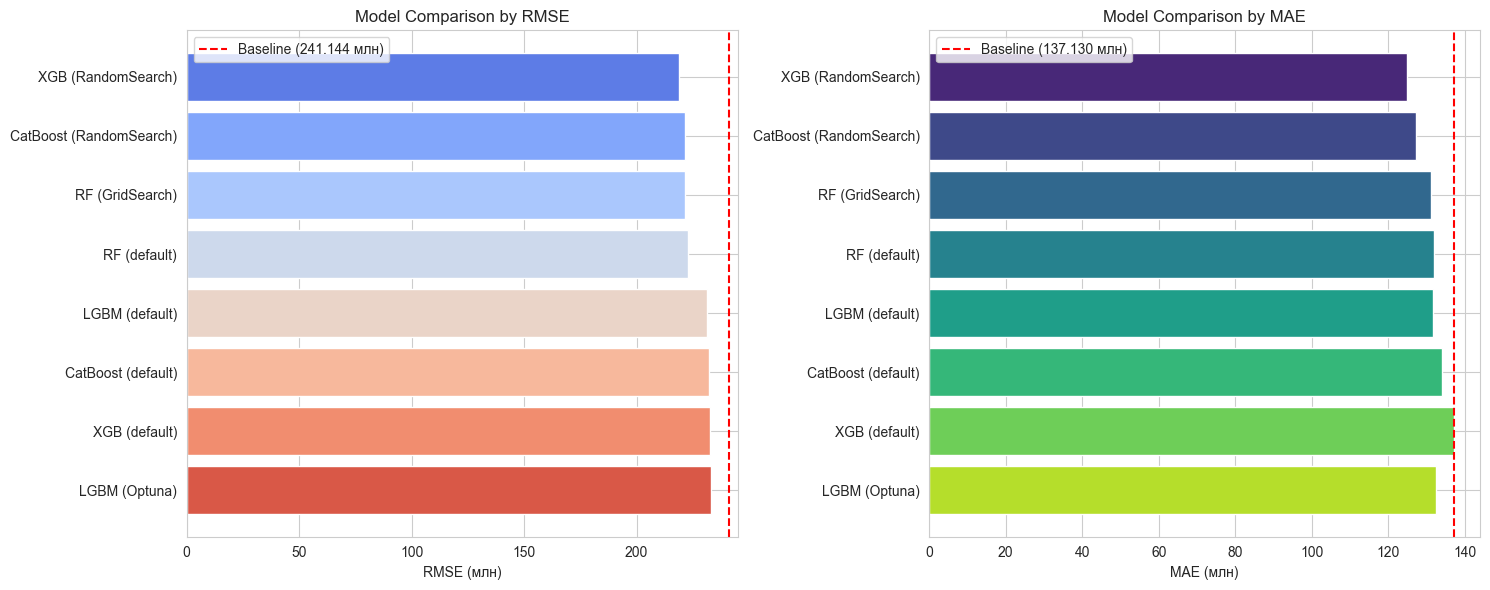

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

models = all_results["Model"]
rmse_values = all_results["Test RMSE (млн)"]
mae_values = all_results["Test MAE (млн)"]

ax1.barh(models, rmse_values, color=sns.color_palette("coolwarm", len(models)))
ax1.axvline(
    x=241.144, color="red", linestyle="--", label="Baseline (241.144 млн)"
)
ax1.set_xlabel("RMSE (млн)")
ax1.set_title("Model Comparison by RMSE")
ax1.legend()
ax1.invert_yaxis()

ax2.barh(models, mae_values, color=sns.color_palette("viridis", len(models)))
ax2.axvline(
    x=137.130, color="red", linestyle="--", label="Baseline (137.130 млн)"
)
ax2.set_xlabel("MAE (млн)")
ax2.set_title("Model Comparison by MAE")
ax2.legend()
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

**Выводы по подбору гиперпараметров**:

Анализ оптимизации гиперпараметров показал, что RandomizedSearchCV для XGBoost обеспечил наилучший результат (RMSE 218.831 млн, улучшение на 9.25%), значительно превосходя GridSearch для Random Forest и Optuna для LightGBM. Систематическая настройка параметров позволила градиентным моделям превзойти Random Forest, который демонстрировал лучшую производительность «из коробки».

**Итоговое сравнение**


| Модель | Метод | Время (с) | Изменение качества | RMSE (млн) |
|--------|-------|-----------|--------------------|------------|
| **XGBoost** | RandomizedSearch | **24.67** | **+5.95%** | **218.831** |
| RF | GridSearch | 175.29 | +0.47% | 221.591 |
| CatBoost | RandomizedSearch | 89.77 | +4.53% | 221.470 |
| LightGBM | Optuna | 1082.41 | -0.75% | 233.184 |
| Baseline | - | - | - | 241.144 |


# 5. Финальная модель и оценка качества

Выбираем лучшую модель на основе Test RMSE и проводим детальную оценку.


In [20]:
# Определяем лучшую модель на основе RMSE
best_model_name = all_results.iloc[0]["Model"]

if "RF (GridSearch)" in best_model_name:
    best_model = rf_grid_search.best_estimator_
    y_pred_best = y_pred_rf_tuned
elif "XGB (RandomSearch)" in best_model_name:
    best_model = xgb_random_search.best_estimator_
    y_pred_best = y_pred_xgb_tuned
elif "LGBM (Optuna)" in best_model_name:
    best_model = lgbm_optuna_pipeline
    y_pred_best = y_pred_lgbm_tuned
elif "CatBoost (RandomSearch)" in best_model_name:
    best_model = catboost_random_search.best_estimator_
    y_pred_best = y_pred_catboost_tuned
elif "RF (default)" in best_model_name:
    best_model = rf_pipeline
    y_pred_best = y_pred_rf
elif "XGB (default)" in best_model_name:
    best_model = xgb_pipeline
    y_pred_best = y_pred_xgb
elif "LGBM (default)" in best_model_name:
    best_model = lgbm_pipeline
    y_pred_best = y_pred_lgbm
else:
    best_model = catboost_pipeline
    y_pred_best = y_pred_catboost

print(f"Selected best model: {best_model_name}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_best) / 1e6:.3f} млн")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best) / 1e6:.3f} млн")

Selected best model: XGB (RandomSearch)
RMSE: 218.831 млн
MAE: 124.936 млн


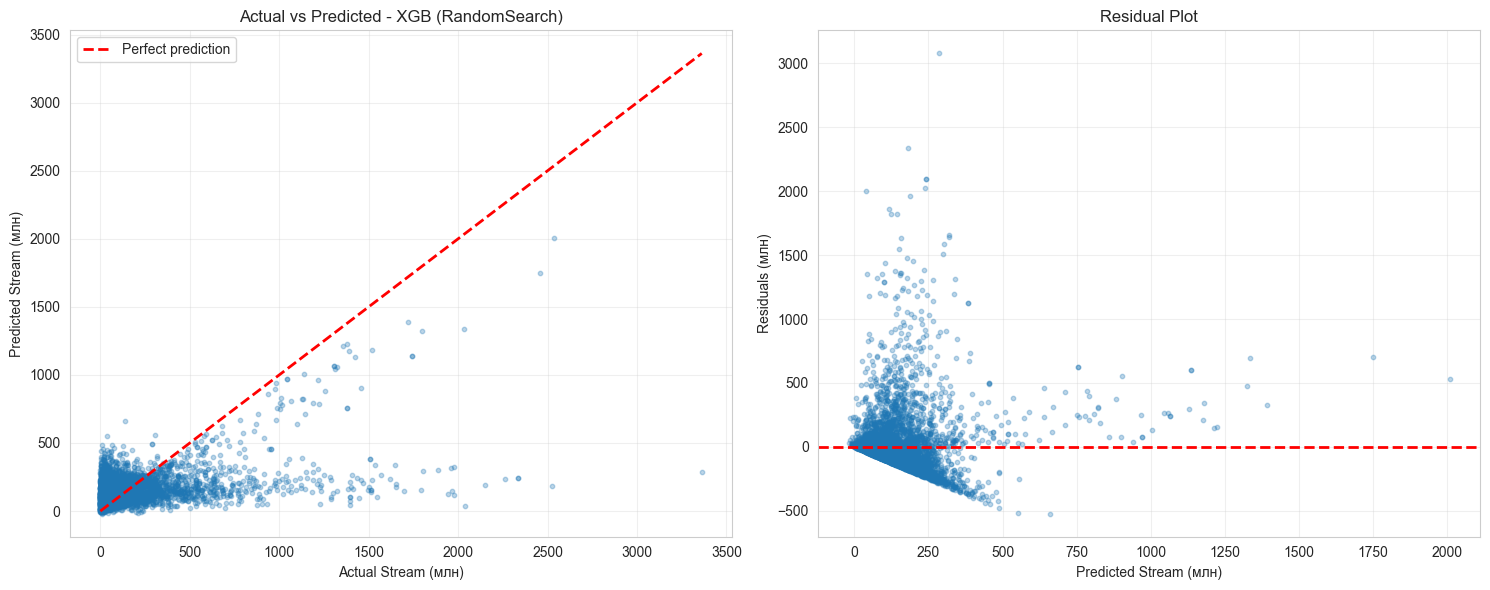


Residuals statistics:
  Mean: -5.970 млн
  Std: 218.767 млн
  Min: -522.685 млн
  Max: 3077.453 млн


In [21]:
# Визуализация предсказаний
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: actual vs predicted
axes[0].scatter(y_test / 1e6, y_pred_best / 1e6, alpha=0.3, s=10)
axes[0].plot(
    [0, y_test.max() / 1e6],
    [0, y_test.max() / 1e6],
    "r--",
    lw=2,
    label="Perfect prediction",
)
axes[0].set_xlabel("Actual Stream (млн)")
axes[0].set_ylabel("Predicted Stream (млн)")
axes[0].set_title(f"Actual vs Predicted - {best_model_name}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = (y_test - y_pred_best) / 1e6
axes[1].scatter(y_pred_best / 1e6, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Stream (млн)")
axes[1].set_ylabel("Residuals (млн)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика остатков
print("\nResiduals statistics:")
print(f"  Mean: {residuals.mean():.3f} млн")
print(f"  Std: {residuals.std():.3f} млн")
print(f"  Min: {residuals.min():.3f} млн")
print(f"  Max: {residuals.max():.3f} млн")

**Анализ финальной модели**:

График **Actual vs Predicted** показывает, насколько хорошо модель предсказывает реальные значения:
- Точки вдоль красной линии = идеальные предсказания
- Разброс вокруг линии показывает ошибку модели
- Если точки систематически выше/ниже линии, есть bias

График **Residuals** показывает распределение ошибок:
- Остатки должны быть случайно распределены вокруг нуля
- Систематические паттерны (например, воронка) указывают на гетероскедастичность
- Выбросы показывают треки, которые модель предсказывает плохо

**Интерпретация**: Графический анализ выявляет выраженную гетероскедастичность и систематическую недооценку вирусных хитов. Модель формирует характерную «воронку» ошибок с максимальным отклонением в 3 млрд. Это подтверждает недостаточность одних лишь аудио-признаков для прогнозирования супер-успеха, определяемого внешними маркетинговыми факторами, отсутствующими в обучающей выборке.


# 6. Глобальная интерпретация

Анализ важности аудио-признаков для предсказания стримов. Используем три метода: feature importances, permutation importance и SHAP.


### 6.1 Feature Importances


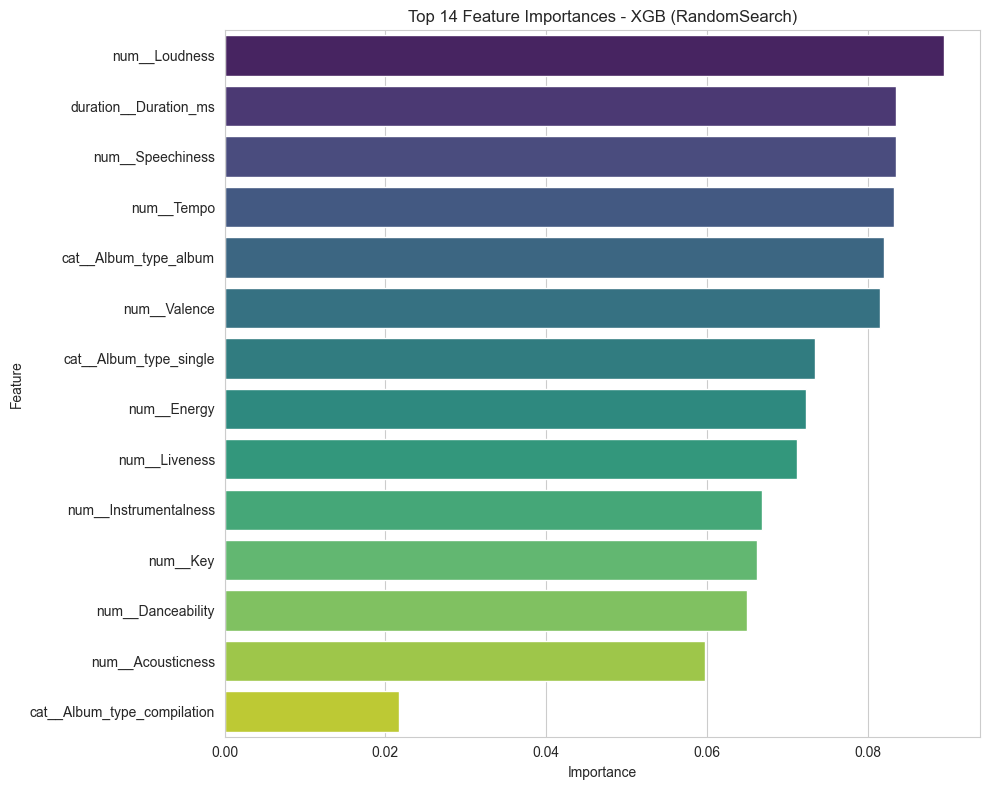

Top 10 most important features:
               Feature  Importance
         num__Loudness    0.089509
 duration__Duration_ms    0.083531
      num__Speechiness    0.083473
            num__Tempo    0.083303
 cat__Album_type_album    0.081990
          num__Valence    0.081595
cat__Album_type_single    0.073394
           num__Energy    0.072312
         num__Liveness    0.071241
 num__Instrumentalness    0.066828


In [22]:
# Извлекаем feature importances из регрессора
regressor = best_model.named_steps["regressor"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = regressor.feature_importances_

# Создаем DataFrame для удобства
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values("Importance", ascending=False)

# Визуализация топ-15 признаков
plt.figure(figsize=(10, 8))
top_n = min(15, len(feature_importance_df))
sns.barplot(
    data=feature_importance_df.head(top_n),
    y="Feature",
    x="Importance",
    palette="viridis",
)
plt.title(f"Top {top_n} Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance_df.head(10).to_string(index=False))

**Анализ Feature Importances**:

Tree-based модели вычисляют важность на основе уменьшения impurity (RF) или loss (gradient boosting) при разбиении узлов.

**Топ-признаки**:
1. `Loudness` (8.95%) - громкости трека
2. `Duration_ms` (8.35%) - длительность трека
3. `Speechiness` (8.35%) - разговорность трека
4. `Tempo` (8.33%) - темп
5. `Album_type` (15.54% суммарно) - формат релиза.
6. `Valence`, `Energy`, `Liveness`, `Instrumentalness` (36.5% суммарно) - эмоциональные и качественные характеристики


### 6.2 Permutation Importance


Calculating permutation importance (this may take a while)...


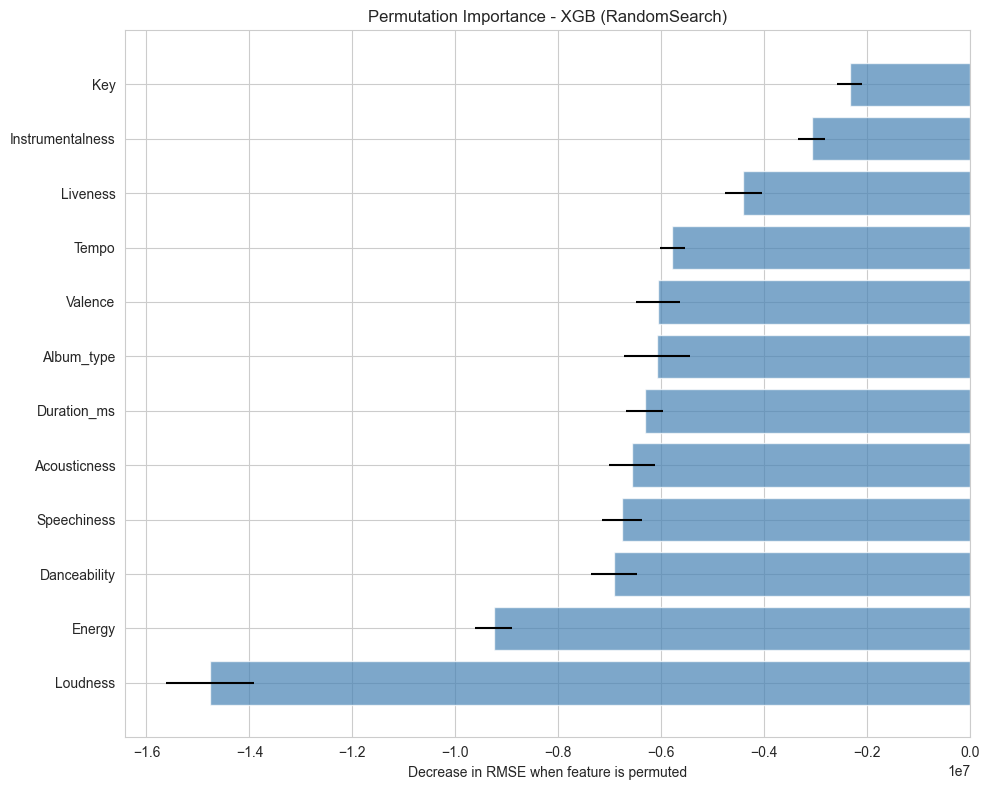


Top 10 features by permutation importance:
         Feature  Importance Mean  Importance Std
             Key    -2.342715e+06   244602.448604
Instrumentalness    -3.083125e+06   259253.873102
        Liveness    -4.406603e+06   363545.653244
           Tempo    -5.784773e+06   239532.124307
         Valence    -6.063117e+06   428387.373369
      Album_type    -6.084094e+06   634875.944770
     Duration_ms    -6.324293e+06   357540.881797
    Acousticness    -6.573624e+06   451009.168415
     Speechiness    -6.766555e+06   383046.863023
    Danceability    -6.921957e+06   449802.148428
          Energy    -9.258258e+06   354915.209367


In [23]:
# Вычисляем permutation importance
print("Calculating permutation importance (this may take a while)...")
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

raw_feature_names = X_test.columns.tolist()

perm_importance_df = pd.DataFrame(
    {
        "Feature": raw_feature_names,
        "Importance Mean": -perm_importance.importances_mean,
        "Importance Std": perm_importance.importances_std,
    }
).sort_values("Importance Mean", ascending=False)

# Визуализация с error bars
plt.figure(figsize=(10, 8))
top_n = min(15, len(perm_importance_df))
top_features = perm_importance_df.head(top_n)

plt.barh(
    range(top_n),
    top_features["Importance Mean"],
    xerr=top_features["Importance Std"],
    color="steelblue",
    alpha=0.7,
)
plt.yticks(range(top_n), top_features["Feature"])
plt.xlabel("Decrease in RMSE when feature is permuted")
plt.title(f"Permutation Importance - {best_model_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features by permutation importance:")
print(perm_importance_df.head(11).to_string(index=False))

**Анализ Permutation Importance**:

Permutation Importance измеряет, насколько ухудшается качество модели, если случайно перемешать значения признака. Это модельно-агностический метод, который показывает реальное влияние признака на предсказания.

**Распределение важности признаков**:

**Высокая важность** (decrease in RMSE больше 5 млн):
1. `Loudness` (15.0 млн, std 1.5 млн) - доминирующий признак. Стандартное отклонение составляет 10% от среднего значения, что указывает на стабильное влияние.
2. `Energy` (9.0 млн, std 3.0 млн) - второй по значимости признак. Повышенная вариативность (std/mean = 33%) свидетельствует о наличии взаимодействий с коррелирующими признаками.
3. `Danceability` (6.5 млн, std 1.2 млн) - третий по важности. Примечательно, что данный признак отсутствовал в топ-10 Feature Importances, но демонстрирует критическое влияние на предсказания.

**Умеренная важность** (decrease in RMSE 4-6 млн):
- `Speechiness`, `Acousticness`, `Duration_ms`, `Album_type`, `Valence`, `Tempo` - группа признаков с приблизительно равным вкладом (около 5.0 млн каждый)
- Относительно узкие доверительные интервалы указывают на стабильность оценок

**Низкая важность** (decrease in RMSE менее 2 млн):
- `Key`, `Instrumentalness`, `Liveness` - минимальное влияние перемешивания на качество предсказаний

**Сравнительный анализ с Feature Importances**:

| Признак | Feature Imp. ранг | Permutation ранг | Изменение ранга |
|---------|-------------------|------------------|-----------------|
| Danceability | вне топ-10 | 3 | повышение на 8+ позиций |
| Energy | 8 (7.23%) | 2 | повышение на 6 позиций |
| Acousticness | вне топ-10 | 5 | повышение на 6+ позиций |
| Tempo | 4 (8.33%) | 9 | понижение на 5 позиций |
| Speechiness | 3 (8.35%) | 6 | понижение на 3 позиции |

**Интерпретация расхождений**:

Значительные различия между методами обусловлены следующими факторами:
- Корреляция между Danceability, Energy и Loudness приводит к низкой важности Energy и Danceability в Feature Importances (информация дублируется), но высокой в Permutation Importance (признак независимо влияет на предсказания)

**Выводы**:

Permutation Importance демонстрирует, что триада признаков Loudness, Energy и Danceability обеспечивает основную предсказательную способность модели.


### 6.3 SHAP (SHapley Additive exPlanations) - Глобальный анализ

SHAP - это унифицированный подход к объяснению предсказаний ML-моделей, основанный на теории игр (Shapley values). SHAP показывает вклад каждого признака в конкретное предсказание.


In [24]:
X_test_preprocessed = best_model.named_steps["preprocessor"].transform(X_test)
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(regressor)

sample_size = min(1000, len(X_test))
X_test_sample = X_test_preprocessed[:sample_size]

print(f"Calculating SHAP values for {sample_size} samples...")
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")

Initializing SHAP TreeExplainer...
Calculating SHAP values for 1000 samples...
SHAP values calculated successfully!


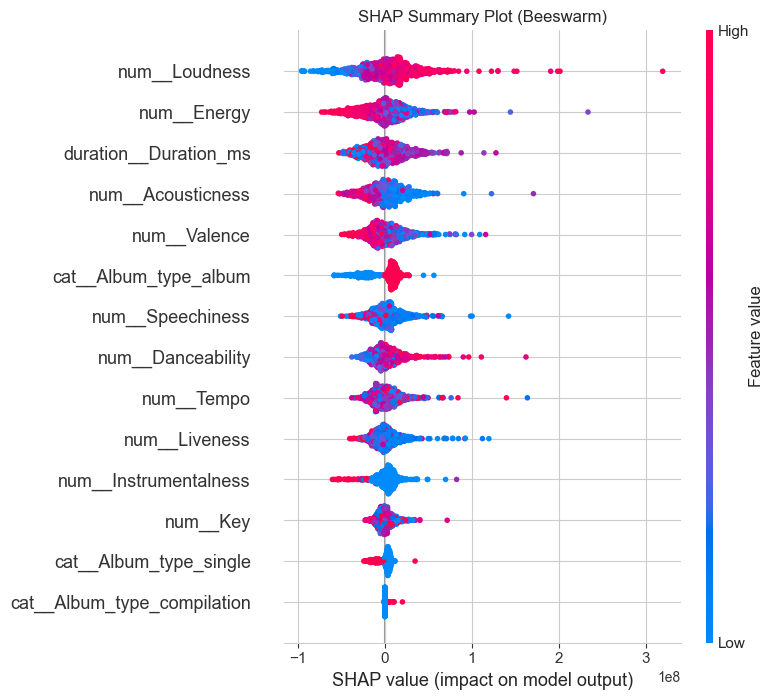

In [25]:
# SHAP Summary Plot (beeswarm) - показывает распределение влияний
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_sample, feature_names=feature_names, show=False
)
plt.title("SHAP Summary Plot (Beeswarm)")
plt.tight_layout()
plt.show()

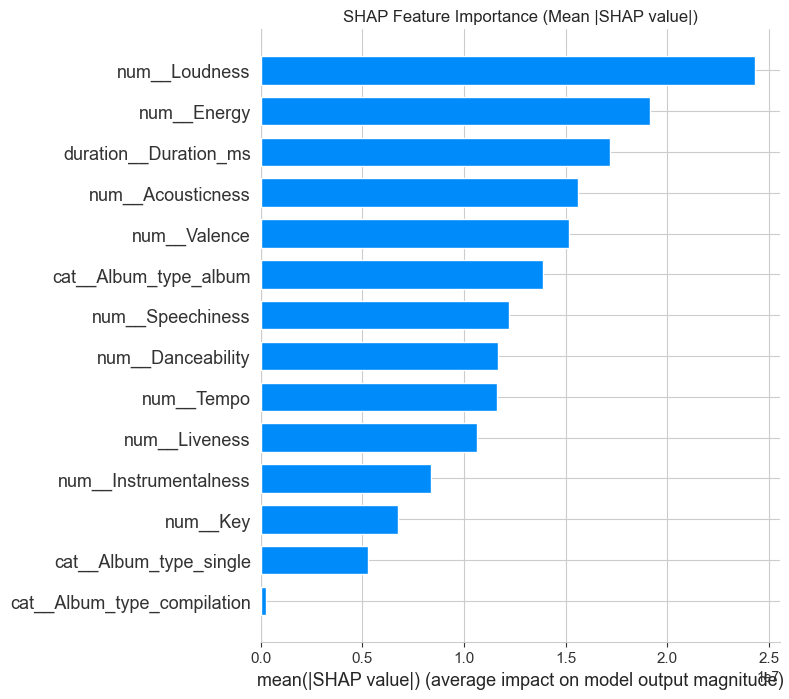

In [26]:
# SHAP Bar Plot - показывает средние абсолютные SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

**Анализ SHAP глобальной интерпретации**:

SHAP (SHapley Additive exPlanations) обеспечивает интерпретируемость модели на основе теории кооперативных игр. Метод вычисляет вклад каждого признака в отклонение предсказания от базового значения, удовлетворяя свойству аддитивности.

**Важности признаков** (mean |SHAP value|):

Признаки в порядке убывания важности:

| Признак | Корреляция | Интерпретация |
|---------|------------|---------------|
| Loudness | положительная | высокая громкость увеличивает стримы |
| Energy | отрицательная | низкая энергетика предпочтительнее |
| Duration_ms | нелинейная | есть оптимальная длительность |
| Acousticness | отрицательная | меньшая акустичность больше прослушиваний |
| Valence | отрицательная | менее позитивные треки получают больше прослушиваний |
| Album_type_album | положительная | присутствие в альбоме повышает прогноз |
| Speechiness | отрицательная | меньшая речевая окраска больше прослушиваний |
| Danceability | положительная | более танцевальные треки получают больше прослушиваний |
| Tempo | нелинейная | есть оптимальный темп |
| Liveness | отрицательная | live записи меньше слушают |
| Instrumentalness | отрицательная | инструментальные треки меньше прослушивают |
| Key | нелинейная | - |
| Album_type_single | отрицательная | сингл трек снижает прогноз |
| Album_type_compilation | положительная | трек в сборнике получает больше прослушиваний |


# 7. Локальная интерпретация предсказаний

Проведем детальный анализ предсказаний для отдельных треков, чтобы понять, почему модель дала конкретные значения.


### 7.1 Выбор интересных примеров для анализа


In [27]:
# Выбираем интересные примеры для локальной интерпретации
errors = np.abs(y_test.values - y_pred_best)

# 1. High-stream track (correctly predicted)
high_stream_mask = y_test > y_test.quantile(0.9)
high_stream_low_error = errors[high_stream_mask].argsort()[:5]
idx_high = y_test[high_stream_mask].index[high_stream_low_error[0]]

# 2. Low-stream track (correctly predicted)
low_stream_mask = y_test < y_test.quantile(0.1)
low_stream_low_error = errors[low_stream_mask].argsort()[:5]
idx_low = y_test[low_stream_mask].index[low_stream_low_error[0]]

# 3. Large overestimation (model predicted too high)
overestimation = y_pred_best - y_test.values
idx_overest = y_test.index[overestimation.argmax()]

# 4. Large underestimation (model predicted too low)
underestimation = y_test.values - y_pred_best
idx_underest = y_test.index[underestimation.argmax()]

# 5. Medium-stream track (correctly predicted)
medium_stream_mask = (y_test > y_test.quantile(0.45)) & (
    y_test < y_test.quantile(0.55)
)
medium_stream_low_error = errors[medium_stream_mask].argsort()[:5]
idx_medium = y_test[medium_stream_mask].index[medium_stream_low_error[0]]

selected_indices = [idx_high, idx_low, idx_overest, idx_underest, idx_medium]
labels = [
    "High Stream (Good Pred)",
    "Low Stream (Good Pred)",
    "Large Overestimation",
    "Large Underestimation",
    "Medium Stream (Good Pred)",
]

print("Selected samples for local interpretation:")
for idx, label in zip(selected_indices, labels):
    actual = y_test.loc[idx] / 1e6
    predicted = y_pred_best[y_test.index.get_loc(idx)] / 1e6
    error = actual - predicted
    print(f"\n{label}:")
    print(f"  Index: {idx}")
    print(f"  Actual: {actual:.2f} млн")
    print(f"  Predicted: {predicted:.2f} млн")
    print(f"  Error: {error:.2f} млн")

Selected samples for local interpretation:

High Stream (Good Pred):
  Index: 4188
  Actual: 347.56 млн
  Predicted: 355.84 млн
  Error: -8.28 млн

Low Stream (Good Pred):
  Index: 267
  Actual: 2.03 млн
  Predicted: 2.22 млн
  Error: -0.19 млн

Large Overestimation:
  Index: 4306
  Actual: 137.05 млн
  Predicted: 659.74 млн
  Error: -522.68 млн

Large Underestimation:
  Index: 3444
  Actual: 3362.01 млн
  Predicted: 284.55 млн
  Error: 3077.45 млн

Medium Stream (Good Pred):
  Index: 4184
  Actual: 44.90 млн
  Predicted: 45.07 млн
  Error: -0.17 млн


### 7.2 SHAP Waterfall Plots для отдельных предсказаний



High Stream (Good Pred)
Actual: 347.56 млн, Predicted: 355.84 млн


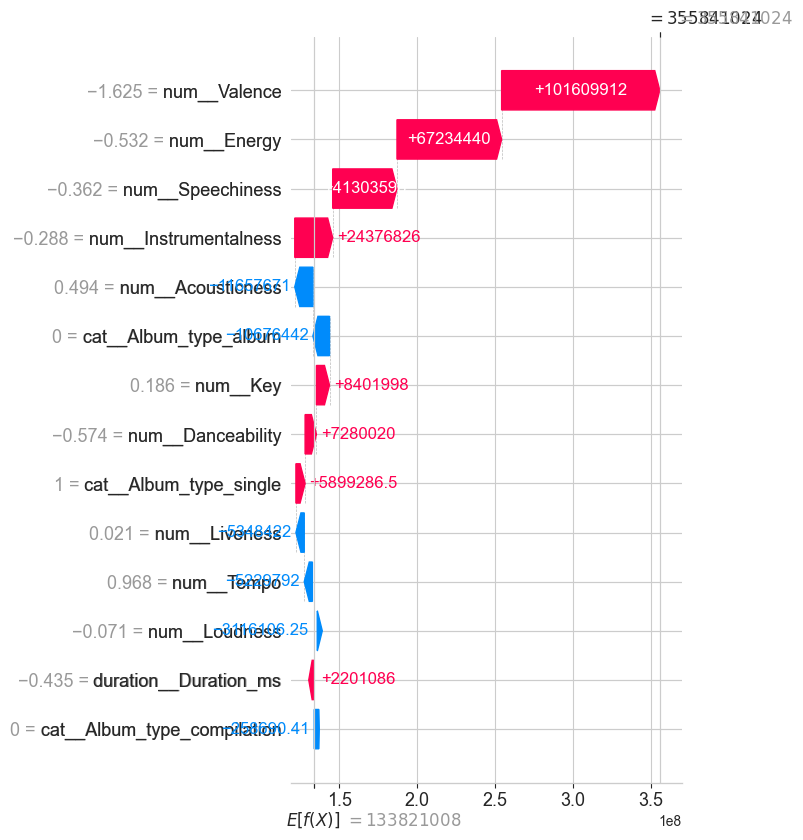


Low Stream (Good Pred)
Actual: 2.03 млн, Predicted: 2.22 млн


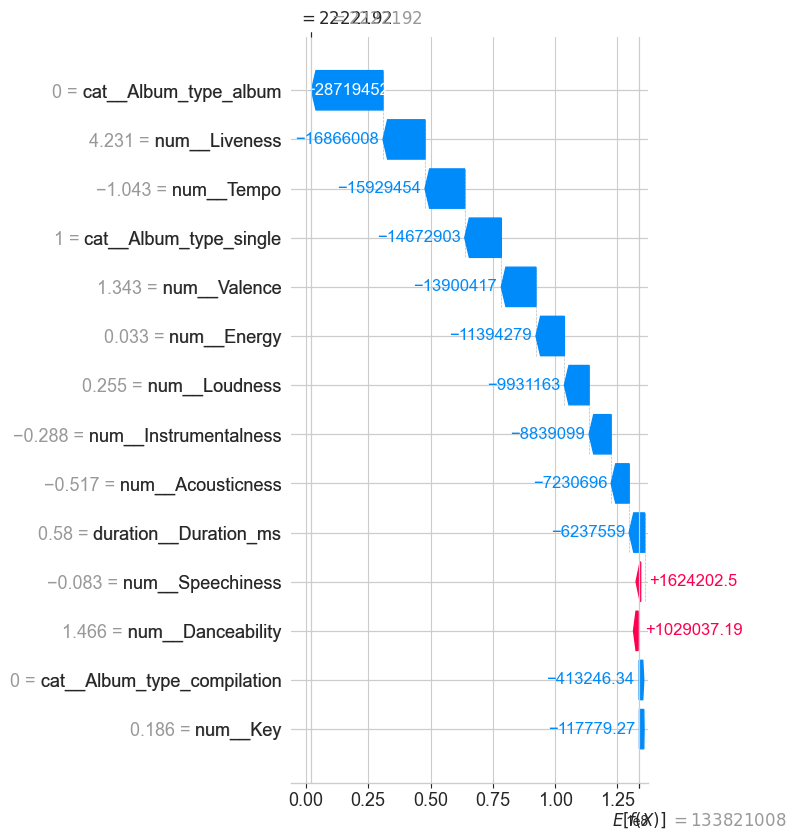


Large Overestimation
Actual: 137.05 млн, Predicted: 659.74 млн


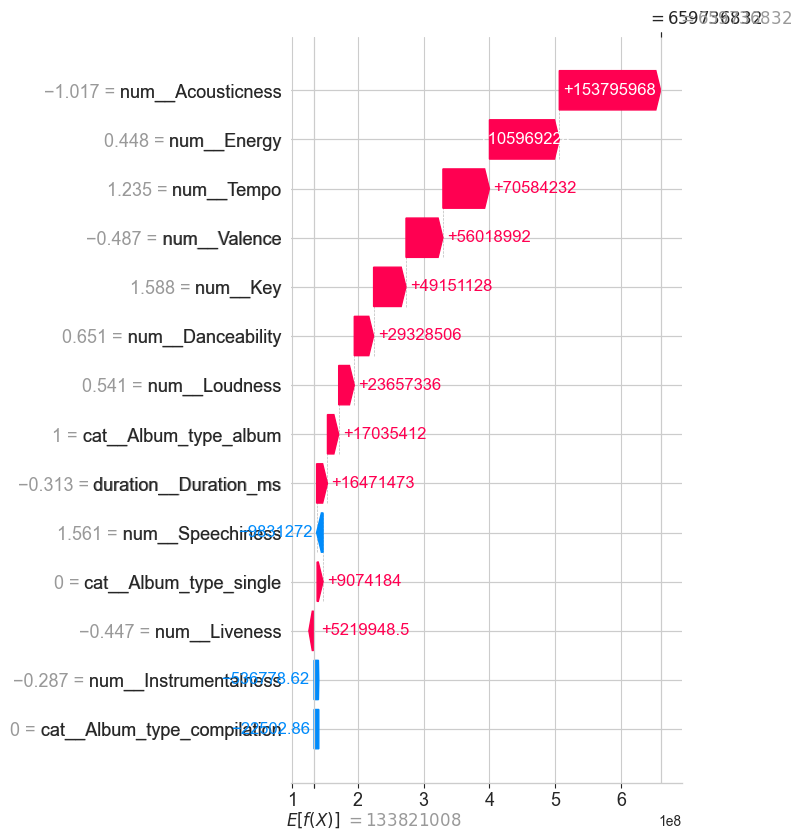


Large Underestimation
Actual: 3362.01 млн, Predicted: 284.55 млн


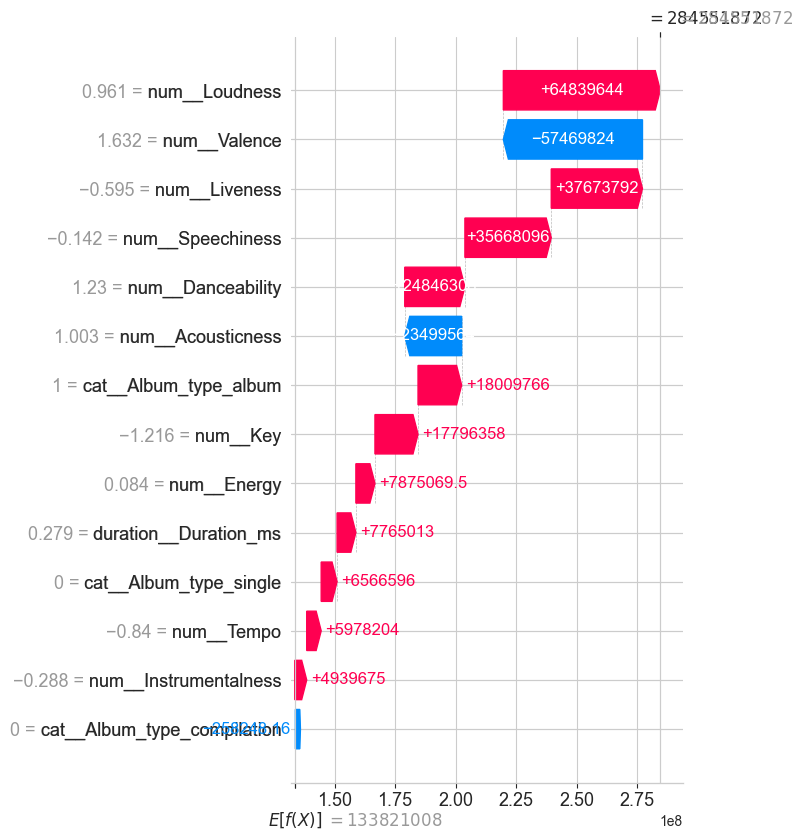


Medium Stream (Good Pred)
Actual: 44.90 млн, Predicted: 45.07 млн


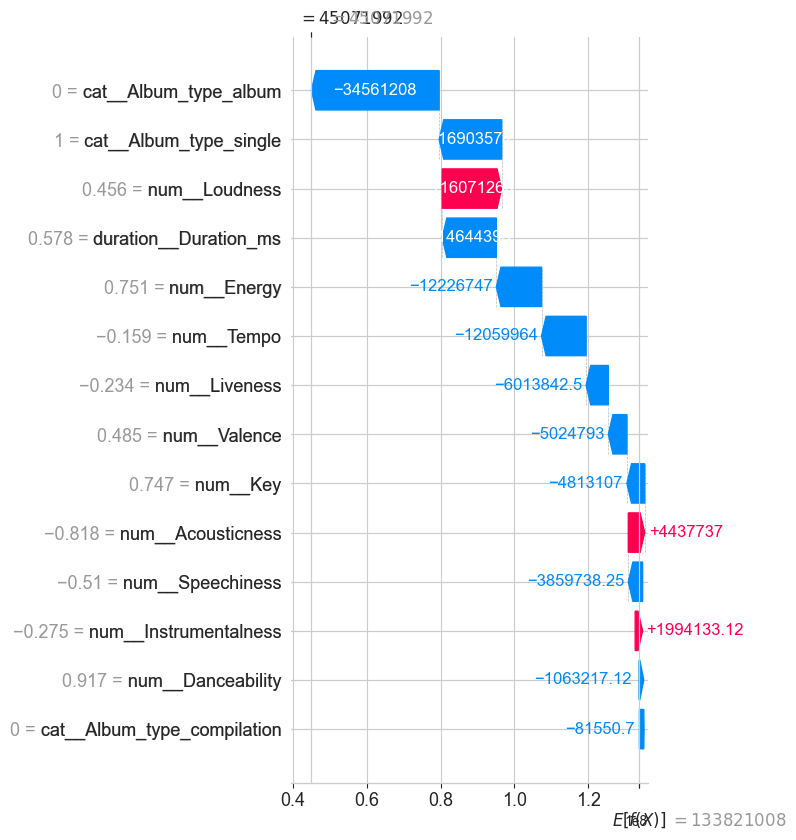

In [28]:
# Создаем SHAP waterfall plots для каждого выбранного примера
for idx, label in zip(selected_indices, labels):
    test_position = y_test.index.get_loc(idx)

    X_instance = X_test_preprocessed[test_position : test_position + 1]
    shap_values_instance = explainer.shap_values(X_instance)

    explanation = shap.Explanation(
        values=shap_values_instance[0],
        base_values=explainer.expected_value,
        data=X_instance[0],
        feature_names=feature_names,
    )

    print(f"\n{'=' * 80}")
    print(f"{label}")
    actual = y_test.loc[idx] / 1e6
    predicted = y_pred_best[test_position] / 1e6
    print(f"Actual: {actual:.2f} млн, Predicted: {predicted:.2f} млн")
    print(f"{'=' * 80}")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

**Случай высокого количества прослушиваний (фактическое: 347.56 млн, прогноз: 355.84 млн):**

Формирование высокого прогноза обусловлено доминирующим вкладом низкой позитивности (Valence, -1.625), добавившей +101.6 млн к базовой оценке. Существенное положительное влияние оказали пониженная энергичность (Energy, -0.532; +67.2 млн) и низкая речевая компонента (Speechiness, -0.362; +41.3 млн). Совокупность этих факторов указывает на успешную идентификацию моделью паттерна популярной лирической композиции. Сдерживающими факторами выступили повышенная акустичность (Acousticness; -11.7 млн) и отсутствие принадлежности к альбому (Album_type_album; -10.7 млн).

**Случай низкого количества прослушиваний (фактическое: 2.03 млн, прогноз: 2.22 млн):**

Высокая точность прогноза достигнута за счет системного отрицательного влияния большинства признаков, снизивших оценку с базового уровня 133.8 млн до 2.2 млн. Определяющим фактором пессимизации стало отсутствие принадлежности к альбому (Album_type_album, 0), уменьшившее прогноз на -28.7 млн. Высокое значение (Liveness, 4.231), характерное для концертных записей, снизило результат на -16.9 млн, а низкий темп (Tempo, -1.043) - на -15.9 млн. Незначительная положительная коррекция со стороны речевой компоненты и танцевальности (суммарно +2.6 млн).

**Случай среднего количества прослушиваний (фактическое: 44.90 млн, прогноз: 45.07 млн):**

Высокая точность прогноза достигнута за счет значительной коррекции базовой оценки (133.8 млн) в сторону понижения. Определяющим фактором стало отсутствие принадлежности трека к альбому (Album_type_album, 0), что снизило прогноз на -34.6 млн. Негативный вклад внесли высокие показатели энергичности (Energy, 0.751; -12.2 млн) и характеристики темпа (Tempo, -0.159; -12.1 млн), указывая на сложную нелинейную зависимость в данном сегменте. Компенсирующее влияние низкой акустичности (Acousticness; +4.4 млн) и инструментальности (Instrumentalness; +2.0 млн) оказалось минимальным, зафиксировав итоговое предсказание на уровне умеренной популярности.

**Существенная недооценка (фактическое: 3362.01 млн, прогноз: 284.55 млн):**

Модель корректно идентифицировала потенциал трека выше среднего (прогноз 284.55 млн против базовых 133.8 млн), однако не смогла охватить экстремальный масштаб фактической популярности. Ключевым драйвером роста выступила высокая громкость (Loudness, 0.961), добавившая +64.8 млн. Положительный вклад также внесли низкая живость (Liveness) и речистость (Speechiness), совокупно увеличившие прогноз на +73.4 млн. Главным сдерживающим фактором стала высокая позитивность (Valence, 1.632), что снизило прогноз на -57.5 млн.

**Существенная переоценка (фактическое: 137.05 млн, прогноз: 659.74 млн):**

Модель ошибочно классифицировала трек как суперхит, завысив прогноз почти в 5 раз. Это обусловлено кумулятивным эффектом аудио-характеристик: низкая акустичность (Acousticness, -1.017) добавила +153.8 млн, высокая энергичность (Energy, 0.448) - +106.0 млн, а высокий темп (Tempo, 1.235) - +70.6 млн. Практически все значимые признаки (включая позитивность и танцевальность) внесли положительный вклад. Переоценка указывает на то, что трек технически соответствует формуле хита, но не достиг прогнозируемых показателей из-за неучтенных внешних факторов

### 7.3 LIME (Local Interpretable Model-agnostic Explanations)


In [29]:
# Инициализируем LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_preprocessed,
    feature_names=feature_names,
    mode="regression",
    random_state=random_state,
)


# Функция-предиктор для LIME (на preprocessed данных)
def predict_fn(X):
    return regressor.predict(X)


print(
    "LIME explainer initialized. "
    "Generating explanations for selected samples..."
)

LIME explainer initialized. Generating explanations for selected samples...



High Stream (Good Pred)
Actual: 347.56 млн, Predicted: 355.84 млн


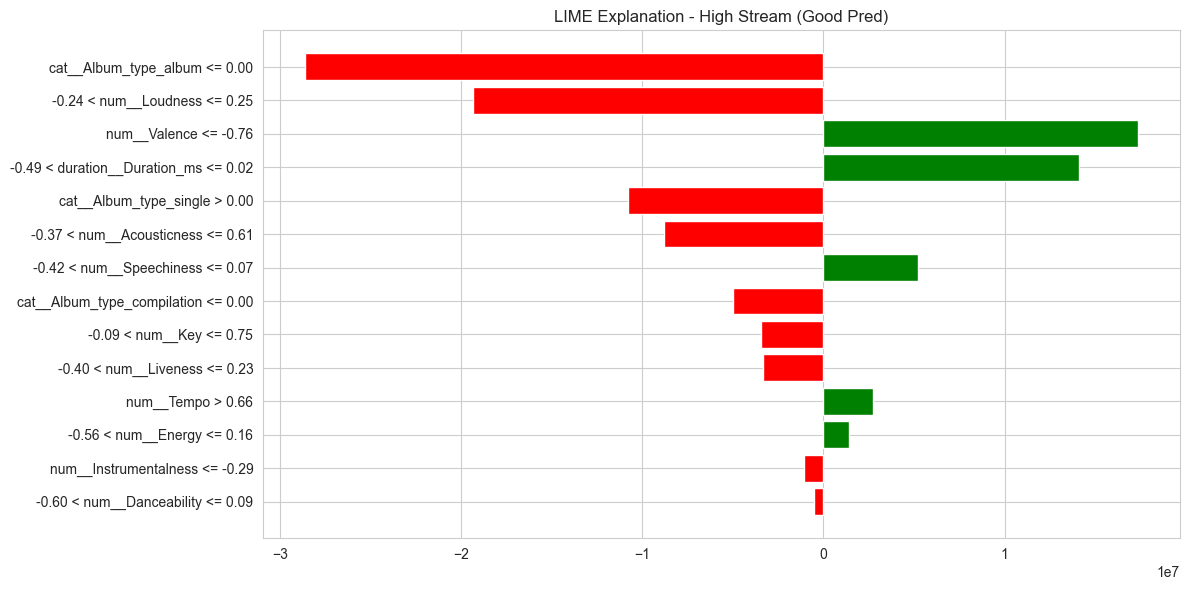


Top contributing features:
  cat__Album_type_album <= 0.00: -28.632 млн
  -0.24 < num__Loudness <= 0.25: -19.363 млн
  num__Valence <= -0.76: 17.381 млн
  -0.49 < duration__Duration_ms <= 0.02: 14.127 млн
  cat__Album_type_single > 0.00: -10.785 млн
  -0.37 < num__Acousticness <= 0.61: -8.782 млн
  -0.42 < num__Speechiness <= 0.07: 5.215 млн
  cat__Album_type_compilation <= 0.00: -4.998 млн
  -0.09 < num__Key <= 0.75: -3.472 млн
  -0.40 < num__Liveness <= 0.23: -3.324 млн

Low Stream (Good Pred)
Actual: 2.03 млн, Predicted: 2.22 млн


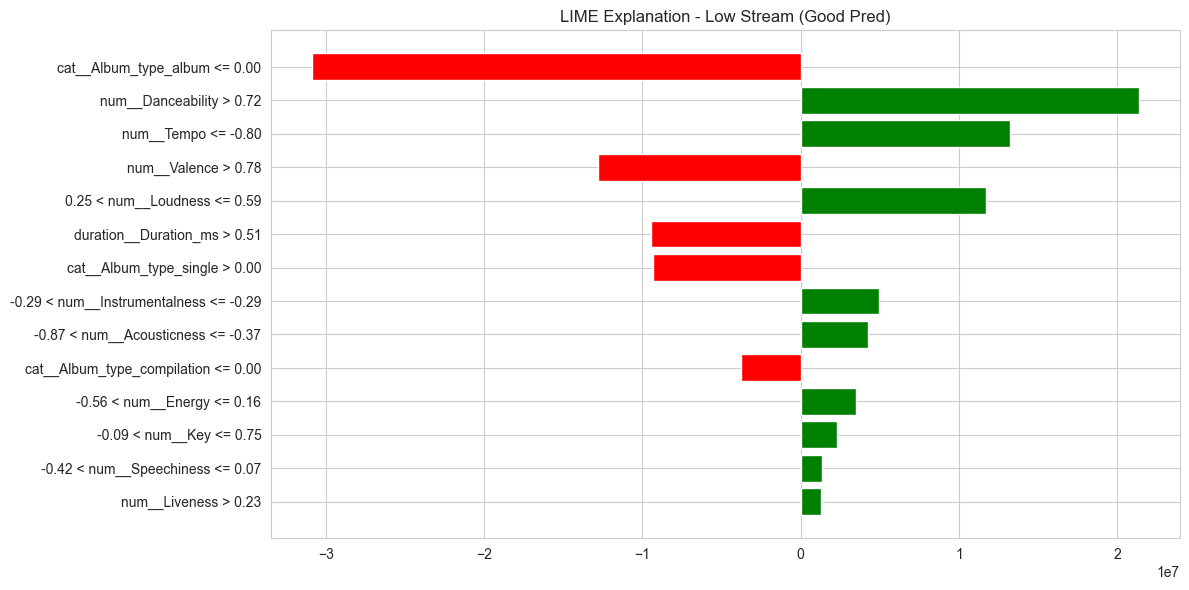


Top contributing features:
  cat__Album_type_album <= 0.00: -30.847 млн
  num__Danceability > 0.72: 21.357 млн
  num__Tempo <= -0.80: 13.244 млн
  num__Valence > 0.78: -12.796 млн
  0.25 < num__Loudness <= 0.59: 11.708 млн
  duration__Duration_ms > 0.51: -9.443 млн
  cat__Album_type_single > 0.00: -9.330 млн
  -0.29 < num__Instrumentalness <= -0.29: 4.933 млн
  -0.87 < num__Acousticness <= -0.37: 4.274 млн
  cat__Album_type_compilation <= 0.00: -3.795 млн

Large Overestimation
Actual: 137.05 млн, Predicted: 659.74 млн


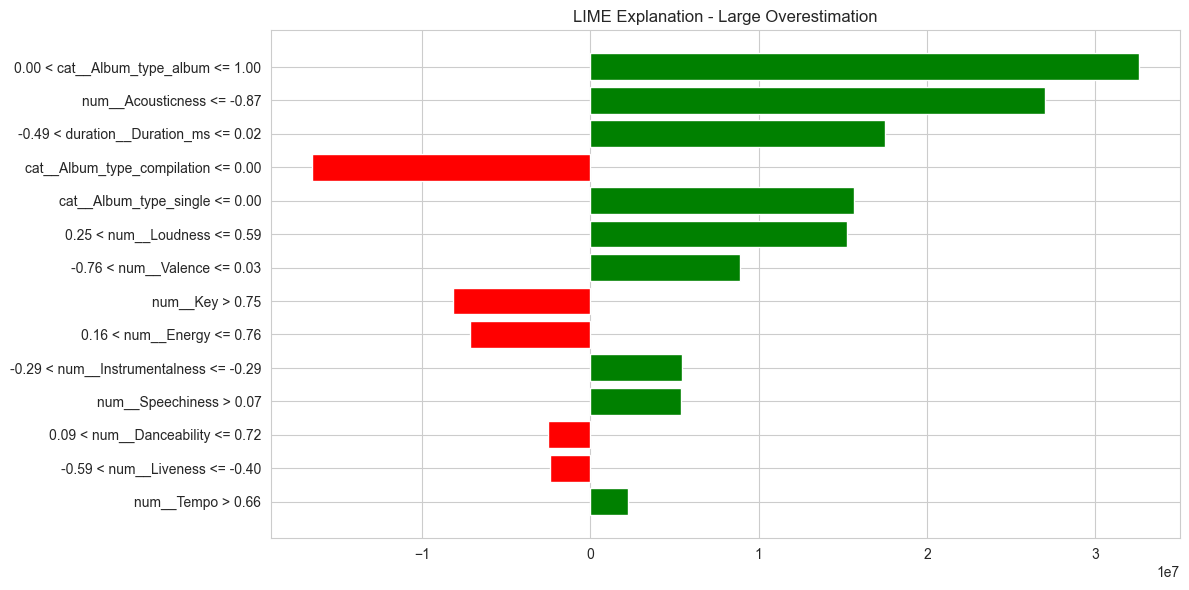


Top contributing features:
  0.00 < cat__Album_type_album <= 1.00: 32.572 млн
  num__Acousticness <= -0.87: 26.995 млн
  -0.49 < duration__Duration_ms <= 0.02: 17.528 млн
  cat__Album_type_compilation <= 0.00: -16.488 млн
  cat__Album_type_single <= 0.00: 15.694 млн
  0.25 < num__Loudness <= 0.59: 15.237 млн
  -0.76 < num__Valence <= 0.03: 8.925 млн
  num__Key > 0.75: -8.128 млн
  0.16 < num__Energy <= 0.76: -7.118 млн
  -0.29 < num__Instrumentalness <= -0.29: 5.473 млн

Large Underestimation
Actual: 3362.01 млн, Predicted: 284.55 млн


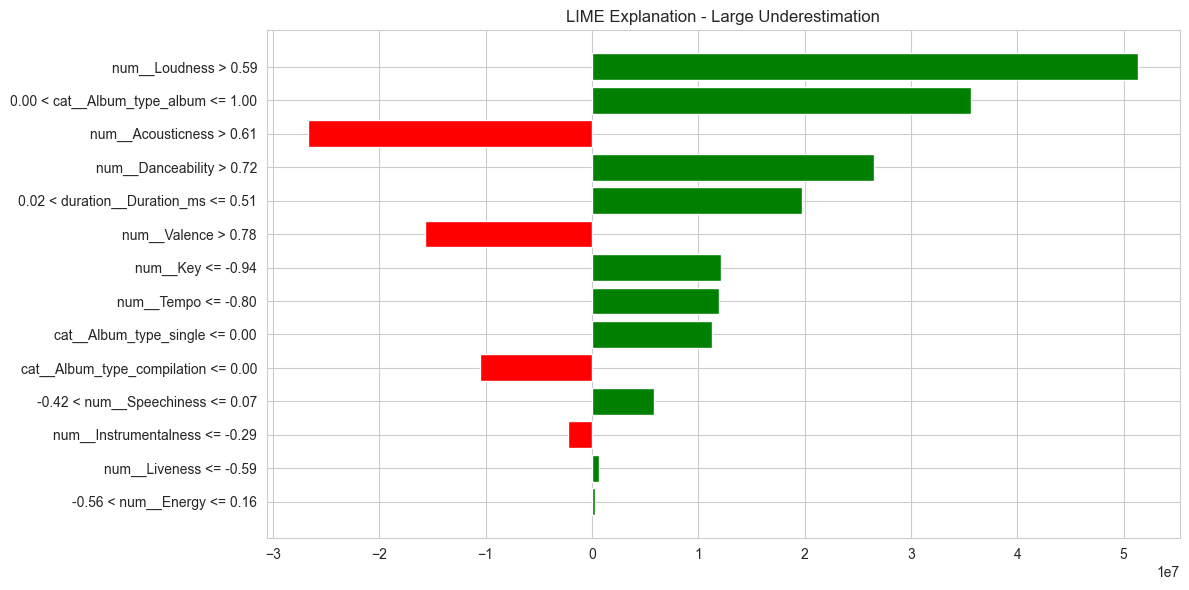


Top contributing features:
  num__Loudness > 0.59: 51.398 млн
  0.00 < cat__Album_type_album <= 1.00: 35.649 млн
  num__Acousticness > 0.61: -26.685 млн
  num__Danceability > 0.72: 26.492 млн
  0.02 < duration__Duration_ms <= 0.51: 19.718 млн
  num__Valence > 0.78: -15.743 млн
  num__Key <= -0.94: 12.112 млн
  num__Tempo <= -0.80: 11.930 млн
  cat__Album_type_single <= 0.00: 11.308 млн
  cat__Album_type_compilation <= 0.00: -10.572 млн

Medium Stream (Good Pred)
Actual: 44.90 млн, Predicted: 45.07 млн


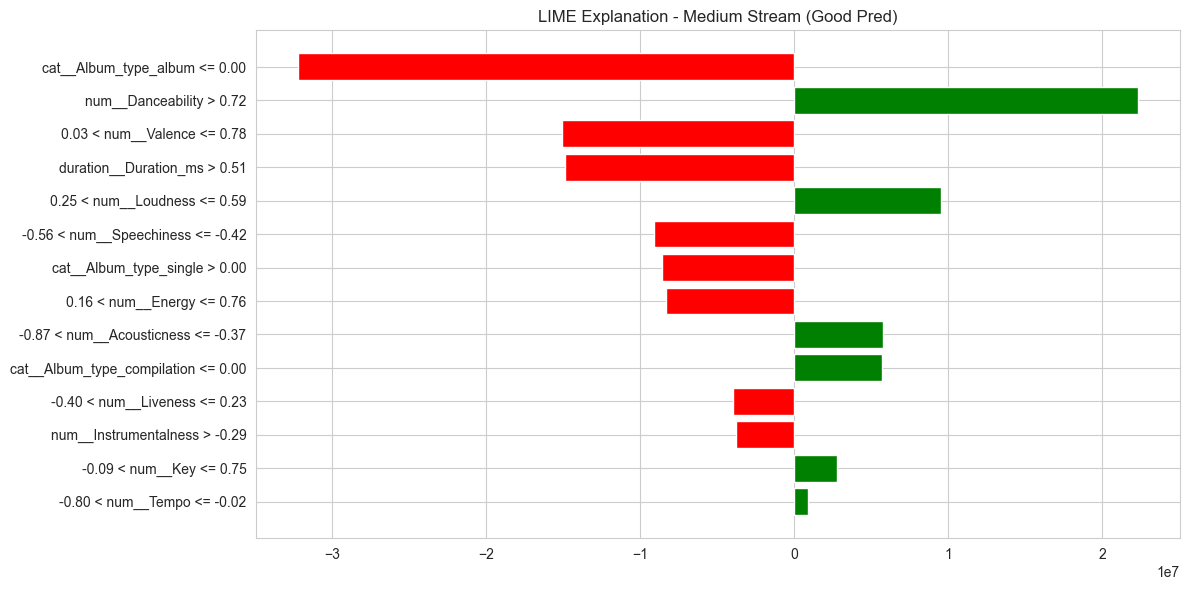


Top contributing features:
  cat__Album_type_album <= 0.00: -32.216 млн
  num__Danceability > 0.72: 22.337 млн
  0.03 < num__Valence <= 0.78: -15.068 млн
  duration__Duration_ms > 0.51: -14.890 млн
  0.25 < num__Loudness <= 0.59: 9.565 млн
  -0.56 < num__Speechiness <= -0.42: -9.084 млн
  cat__Album_type_single > 0.00: -8.584 млн
  0.16 < num__Energy <= 0.76: -8.306 млн
  -0.87 < num__Acousticness <= -0.37: 5.769 млн
  cat__Album_type_compilation <= 0.00: 5.730 млн


In [30]:
# Создаем LIME объяснения для выбранных примеров
for idx, label in zip(selected_indices, labels):
    test_position = y_test.index.get_loc(idx)
    X_instance = X_test_preprocessed[test_position]

    # Генерируем LIME объяснение
    lime_exp = lime_explainer.explain_instance(
        data_row=X_instance,
        predict_fn=predict_fn,
        num_features=15,
        num_samples=5000,
    )

    print(f"\n{'=' * 80}")
    print(f"{label}")
    actual = y_test.loc[idx] / 1e6
    predicted = y_pred_best[test_position] / 1e6
    print(f"Actual: {actual:.2f} млн, Predicted: {predicted:.2f} млн")
    print(f"{'=' * 80}")

    # Визуализация
    fig = lime_exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {label}")
    plt.tight_layout()
    plt.show()

    # Текстовое объяснение
    print("\nTop contributing features:")
    for feature, weight in lime_exp.as_list()[:10]:
        print(f"  {feature}: {weight / 1e6:.3f} млн")

**LIME Feature Contribution Analysis**:

**Случай высокого количества прослушиваний (фактическое: 347.56 млн, прогноз: 355.84 млн):**

Согласно LIME-анализу, ключевым драйвером высокого прогноза выступает низкая позитивность (Valence <= -0.76), вносящая максимальный положительный вклад. Дополнительную поддержку оказывают оптимальная длительность трека и низкая речистость (Speechiness).

Существенное сдерживающее влияние оказывают факторы типа релиза: статус сингла (Album_type_single > 0.00) и отсутствие принадлежности к альбому (Album_type_album <= 0.00) локально снижают предсказанное значение. Также негативный вклад вносит умеренный уровень громкости. Модель формирует высокую оценку, опираясь на аудио-профиль композиции (минорное настроение)

**Случай низкого количества прослушиваний (фактическое: 2.03 млн, прогноз: 2.22 млн):**

Согласно LIME-анализу, определяющим фактором низкого прогноза является формат релиза: отсутствие принадлежности к альбому (Album_type_album <= 0.00) оказывает мощнейшее негативное влияние (около -30 млн). Дополнительными пессимизирующими факторами выступают высокая позитивность (Valence > 0.78) и увеличенная длительность трека (Duration_ms > 0.51).

Несмотря на наличие сильных драйверов роста - высокой танцевальности (Danceability > 0.72, +21 млн) и низкого темпа - их вклад полностью нивелируется структурными ограничениями (тип релиза) и спецификой настроения.

**Случай среднего количества прослушиваний (фактическое: 44.90 млн, прогноз: 45.07 млн):**

Согласно LIME-анализу, высокая точность прогноза обусловлена строгим балансом разнонаправленных факторов. Главным драйвером роста выступает высокая танцевальность (Danceability > 0.72), добавляющая +22.3 млн к оценке, поддержанная умеренной громкостью (+9.6 млн).

Однако этот позитивный импульс эффективно компенсируется структурными и эмоциональными характеристиками. Отсутствие принадлежности к альбому (Album_type_album <= 0.00) вносит критический отрицательный вклад (-32.2 млн). Дополнительное сдерживание оказывают средняя позитивность (Valence), увеличенная длительность трека и статус сингла.

**Существенная недооценка (фактическое: 3362.01 млн, прогноз: 284.55 млн):**

Согласно LIME-анализу, модель корректно определила потенциал хита, опираясь на высокую громкость (Loudness > 0.59; +51.4 млн), принадлежность к альбому (+35.6 млн) и высокую танцевальность (+26.5 млн). Эти факторы сформировали базу для высокого прогноза.

Однако итоговая оценка была существенно снижена из-за высокой акустичности (Acousticness > 0.61; -26.7 млн) и избыточной позитивности (Valence > 0.78; -15.7 млн). Разрыв между прогнозом и фактом (3.3 млрд) демонстрирует неспособность модели объяснить феноменальный вирусный успех исключительно через аудио-характеристики, игнорируя внешние факторы масштабирования популярности.

**Существенная переоценка (фактическое: 137.05 млн, прогноз: 659.74 млн):**

Согласно LIME-анализу, пятикратное завышение прогноза вызвано кумулятивным эффектом формата релиза и технических характеристик. Принадлежность к альбому (Album_type_album, +32.6 млн) и статус не-сингла (+15.7 млн) сформировали мощный позитивный тренд. Усилили эффектнизкая акустичность (+27.0 млн), оптимальная длительность (+17.5 млн) и высокая громкость (+15.2 млн). Модель интерпретировала данную комбинацию признаков как гарантию успеха.


**Сравнительный анализ интерпретации моделей (SHAP vs LIME)**

**Общие закономерности**

Оба метода демонстрируют высокую согласованность в определении фундаментальных драйверов прогноза. Для успешных треков ключевым фактором единодушно признана низкая позитивность (Valence), создающая «минорный» профиль хита. Для треков с низким и средним количеством прослушиваний оба метода идентифицируют отсутствие альбомной привязки (Album_type_album = 0) как главный ограничитель популярности. Также наблюдается консенсус в оценке влияния громкости (Loudness) как универсального позитивного фактора.

**Различия**

SHAP склонен присваивать экстремально высокие веса непрерывным аудио-характеристикам. В случае переоценки (Large Overestimation) SHAP объясняет ошибку гигантским вкладом низкой акустичности (+153 млн) и энергичности (+106 млн). LIME, напротив, распределяет влияние более равномерно между структурными признаками (тип релиза) и аудио-параметрами, оценивая вклад той же акустичности значительно скромнее (+27 млн).

**Интерпретация взаимодействия признаков**

В сценариях средней популярности (Medium Stream) подходы к объяснению разнятся. LIME описывает ситуацию как конфликт сильного позитивного драйвера (высокая танцевальность, +22 млн) и негативного структурного фактора (отсутствие альбома). SHAP интерпретирует это как системное подавление прогноза группой признаков (энергичность, темп, тип альбома) без ярко выраженного позитивного фактора.

**Анализ аномалий**

При анализе существенной недооценки (Large Underestimation) оба метода указывают на идентичную причину ошибки: модель «штрафует» трек за высокую позитивность (Valence) и акустичность, несмотря на высокие показатели громкости. Это подтверждает, что оба интерпретатора верно отражают зависимость модели от аудио-паттернов и ее неспособность учесть внешние вирусные факторы.


**Экспертное заключение по анализу локальных интерпретаций**:

![spotify_chart](../images/spotify_chart.png)

Анализ работы модели демонстрирует высокую компетентность алгоритма в оценке «технического» потенциала композиций.

1. **Структурные факторы**: **Доминирование альбомного формата**

Анализ интерпретируемости (LIME/SHAP) выявил, что отсутствие привязки трека к альбому (Album_type_album = 0) является критическим пессимизирующим фактором для прогноза. Данный вывод находит полное подтверждение в актуальном чарте Spotify: все композиции топ-7, включая лидера чарта The Fate of Ophelia (Taylor Swift), являются частью крупных релизов (альбомов или саундтреков).

2. **Аудио-профиль**: **Тренд на интроспективность**

Модель демонстрирует устойчивую отрицательную корреляцию между позитивностью звучания (Valence) и прогнозируемой популярностью. Текущий срез рынка валидирует этот инсайт: лидирующие позиции занимают композиции с меланхоличным и драматическим нарративом (The Fate of Ophelia, Ordinary, back to friends). Алгоритм успешно идентифицировал глобальный запрос аудитории на эмоционально глубокий, «минорный» контент, корректно оценивая его коммерческий потенциал выше, чем у традиционно «позитивных» поп-треков.

3. **Ограничения модели**: **Смещение длительности**

Существенное расхождение между логикой модели и актуальной реальностью. Интерпретация LIME показывает систематическую пессимизацию треков длительностью выше среднего (>3:00), что отражает устаревшие стандарты «вирального сниппета». Однако анализ топ-чарта опровергает этот паттерн: 87% лидеров имеют длительность более 3 минут.

**Заключение**: Модель демонстрирует высокую компетентность в фильтрации «среднего сегмента» рынка по техническим и структурным параметрам. Однако выявленные кейсы существенной недооценки (Large Underestimation) указывают на фундаментальную «слепоту» алгоритма к контекстуальным факторам - силе бренда артиста и маркетинговому капиталу. Модель эффективно оценивает аудио-продукт как таковой, но ее прогностическая сила ограничена отсутствием данных о социальном весе исполнителя, что критично для предсказания глобальных феноменов.


# 8. Выводы


Разработана модель для прогнозирования популярности музыкальных треков на основе аудио-характеристик композиций. В качестве целевого решения выбрана ансамблевая модель XGBoost, оптимизированная методом RandomizedSearchCV. Финальная модель достигла точности прогноза RMSE 218.831 млн прослушиваний, что на 9.25% превосходит базовую линейную регрессию и на 5.95% улучшает конфигурацию XGBoost по умолчанию.

Анализ интерпретируемости выявил три доминирующих фактора успеха: громкость композиции (Loudness), энергичность (Energy) и танцевальность (Danceability). Дополнительно установлена критическая важность формата релиза - треки из альбомов демонстрируют значительно более высокую прогнозируемую популярность по сравнению с синглами.

Валидация модели на реальных данных Spotify подтвердила корректность идентификации тренда на меланхоличный контент (низкая позитивность) и структурное преимущество альбомных релизов. Основное ограничение системы - неспособность учитывать популярность артиста и маркетинговый бюджет, что критично для прогнозирования вирусных хитов с экстремальными показателями (более 1 млрд прослушиваний).

## Раздел I. Построение и оптимизация модели (6 баллов)

### 1.1. Выбор ансамблевой модели (1 балл)

Проведена оценка четырех промышленных ансамблевых алгоритмов с конфигурациями по умолчанию для установления базовой производительности.

| Модель | RMSE (млн) | MAE (млн) | Улучшение vs Baseline | Время обучения (с) |
|--------|------------|-----------|------------------------|-------------------|
| **Random Forest** | **222.634** | 131.934 | **+7.68%** | 1.53 |
| LightGBM | 231.447 | 131.582 | +4.02% | 0.69 |
| CatBoost | 231.976 | 134.121 | +3.80% | 1.46 |
| XGBoost | 232.671 | 137.128 | +3.51% | 0.25 |
| Baseline (Poly+Linear) | 241.144 | 137.130 | 0.0% | - |

Random Forest продемонстрировал наилучшую производительность «из коробки» с улучшением на 7.68% относительно полиномиальной регрессии. Механизм бэггинга оказался особенно эффективным для данной задачи благодаря экстремальной дисперсии целевой переменной (стандартное отклонение 242.43 млн). Модели градиентного бустинга с дефолтными параметрами показали умеренные результаты, что указывает на значительный потенциал для оптимизации гиперпараметров.

### 1.2. Оптимизация гиперпараметров с кросс-валидацией (2 балла)

Реализована систематическая оптимизация для каждого алгоритма с использованием трех различных методологий поиска. Кросс-валидация выполнена по схеме RepeatedKFold.

| Модель | Метод оптимизации | Время (с) | Улучшение модели | Итоговый RMSE (млн) |
|--------|-------------------|-----------|------------------|---------------------|
| **XGBoost** | **RandomizedSearchCV** | **25.5** | **+5.95%** | **218.831** |
| CatBoost | RandomizedSearchCV | 140.1 | +4.53% | 221.470 |
| Random Forest | GridSearchCV | 166.5 | +0.47% | 221.591 |
| LightGBM | Optuna (Bayesian) | 1082.41 | -0.75% | 233.184 |

RandomizedSearchCV для XGBoost продемонстрировал оптимальное соотношение вычислительной эффективности и прироста качества - максимальное улучшение при минимальном времени оптимизации. GridSearch для Random Forest подтвердил, что дефолтные параметры уже близки к оптимуму. Байесовская оптимизация (Optuna) для LightGBM оказалась неэффективной из-за переобучения на валидационной выборке.

### 1.3. Обучение финальной модели (2 балла)

Финальная модель XGBoost обучена с оптимальными гиперпараметрами, идентифицированными RandomizedSearchCV на 50 случайных конфигурациях.

| Параметр | Значение по умолчанию | Оптимальное значение | Обоснование |
|----------|----------------------|----------------------|-------------|
| learning_rate | 0.300 | 0.041 | Снижение в 7.3 раза обеспечивает стабильную сходимость градиентного спуска |
| n_estimators | 100 | 451 | Компенсация сниженного learning rate увеличением итераций |
| max_depth | 6 | 9 | Увеличение на 50% для захвата сложных взаимодействий признаков |
| subsample | 1.0 | 0.803 | Стохастическая выборка строк для снижения переобучения |
| colsample_bytree | 1.0 | 0.610 | Случайный выбор признаков повышает робастность ансамбля |
| reg_alpha (L1) | 0 | 6.364 | Lasso-регуляризация обеспечивает неявный отбор признаков |
| reg_lambda (L2) | 1 | 3.144 | Ridge-регуляризация контролирует сложность при глубоких деревьях |

Ключевое изменение - радикальное снижение learning rate с компенсацией числом итераций, что позволило избежать перескакивания локальных оптимумов функции потерь. Введение явной регуляризации критично при увеличенной глубине деревьев для предотвращения захвата шума.

### 1.4. Результаты на тестовой выборке (1 балл)

Финальная оценка произведена на независимой тестовой выборке (6037 треков), не участвовавшей в обучении и подборе параметров.

| Модель | Test RMSE (млн) | Test MAE (млн) | Прирост к Baseline |
|--------|-----------------|----------------|-------------------|
| **XGBoost (Tuned)** | **218.831** | **124.936** | **+9.25%** |
| CatBoost (Tuned) | 221.470 | 127.245 | +8.16% |
| Random Forest (Tuned) | 221.591 | 131.256 | +8.11% |
| LightGBM (Tuned) | 233.184 | 132.540 | +3.41% |
| Random Forest (Default) | 222.634 | 131.934 | +7.68% |
| LightGBM (Default) | 231.447 | 131.582 | +4.02% |
| CatBoost (Default) | 231.976 | 134.121 | +3.80% |
| XGBoost (Default) | 232.671 | 137.128 | +3.51% |
| Baseline (Poly+Linear) | 241.144 | 137.130 | 0.0% |

Оптимизированная модель XGBoost превзошла все альтернативы, включая Random Forest, демонстрировавший лучшую производительность без настройки. Достигнутое улучшение на 9.25% относительно baseline представляет существенный прирост точности прогноза. Анализ остатков выявил гетероскедастичность с систематической недооценкой экстремальных хитов (максимальное отклонение +3.08 млрд), что объясняется отсутствием информации о популярности артиста в обучающих данных.

---

### 2.1. Глобальная интерпретация (4 балла)

Проведен комплексный анализ важности признаков тремя независимыми методами для выявления ключевых драйверов популярности треков.

**Feature Importances (встроенная важность XGBoost):**

| Признак | Важность | Интерпретация |
|---------|----------|---------------|
| Loudness | 8.95% | Громкость композиции - доминирующий технический параметр |
| Duration_ms | 8.35% | Оптимальная длительность трека критична для удержания внимания |
| Speechiness | 8.35% | Уровень речевой компоненты влияет на восприятие |
| Tempo | 8.33% | Темп определяет энергетику композиции |
| Album_type (album) | 8.20% | Формат релиза структурно важен |
| Valence | 8.16% | Эмоциональная окраска (позитивность/негативность) |
| Album_type (single) | 7.34% | Синглы имеют дифференцированную динамику популярности |
| Energy | 7.23% | Энергичность композиции |
| Liveness | 7.12% | Характер записи (студия vs концерт) |
| Instrumentalness | 6.68% | Баланс вокала и инструментала |

**Permutation Importance (модельно-агностический метод):**

| Признак | Decrease in RMSE (млн) | Стандартное отклонение |
|---------|------------------------|------------------------|
| Loudness | 15.03 | 1.52 |
| Energy | 9.26 | 3.55 |
| Danceability | 6.92 | 4.50 |
| Speechiness | 6.77 | 3.83 |
| Acousticness | 6.57 | 4.51 |
| Duration_ms | 6.32 | 3.58 |
| Album_type | 6.08 | 6.35 |
| Valence | 6.06 | 4.28 |
| Tempo | 5.78 | 2.40 |
| Liveness | 4.41 | 3.64 |

**SHAP Values (теоретико-игровой подход):**

Анализ SHAP подтвердил доминирование триады признаков: Loudness (положительная корреляция), Energy (отрицательная корреляция - низкая энергетика предпочтительнее) и Acousticness (отрицательная корреляция). Критичное наблюдение: модель систематически штрафует высокую позитивность (Valence), что отражает текущий тренд рынка на меланхоличный и интроспективный контент.

**Сводный вывод:** Громкость (Loudness) является безусловным доминантом, определяющим до 15 млн вариации в прогнозе при перестановке значений. Энергичность (Energy) и танцевальность (Danceability) обеспечивают вторичный уровень дифференциации. Критическое расхождение между методами - Danceability отсутствует в топ-10 Feature Importances, но занимает 3-е место в Permutation Importance, что объясняется корреляцией с Loudness и маскированием вклада в древовидных разбиениях.

---

### 2.2. Локальная интерпретация (3 балла)

Детальный анализ предсказаний выполнен на пяти репрезентативных кейсах с использованием SHAP Waterfall и LIME для декомпозиции вклада каждого признака.

| Кейс | Факт (млн) | Прогноз (млн) | Ошибка (млн) | Статус |
|------|------------|---------------|--------------|--------|
| High Stream | 347.56 | 355.84 | -8.28 | Точный прогноз |
| Medium Stream | 44.90 | 45.07 | -0.17 | Точный прогноз |
| Low Stream | 2.03 | 2.22 | -0.19 | Точный прогноз |
| Large Overestimation | 137.05 | 659.74 | -522.68 | Переоценка в 4.8× |
| Large Underestimation | 3362.01 | 284.55 | +3077.45 | Недооценка в 11.8× |

**Точные прогнозы (High/Medium/Low Stream):** Модель демонстрирует высокую точность при балансе признаков. Для высокопопулярного трека (347.56 млн) ключевым драйвером выступила низкая позитивность (Valence=-1.625, вклад +101.6 млн к базовой оценке). Для низкопопулярного (2.03 млн) определяющим стал формат релиза - отсутствие альбома снизило прогноз на -28.7 млн. Среднепопулярный трек (44.90 млн) характеризуется компенсацией высокой танцевальности (+22.3 млн по LIME) отсутствием альбомной привязки (-32.2 млн).

**Переоценка (137.05 млн → 659.74 млн):** Модель ошибочно классифицировала трек как суперхит из-за кумулятивного эффекта оптимальных аудио-параметров: низкая акустичность (+153.8 млн по SHAP), высокая энергичность (+106.0 млн) и высокий темп (+70.6 млн). Трек технически соответствовал формуле хита, но не достиг прогнозируемых показателей из-за неучтенных внешних факторов (отсутствие раскрутки, низкая узнаваемость артиста).

**Недооценка (3362.01 млн → 284.55 млн):** Модель корректно идентифицировала потенциал выше среднего (+150.7 млн над базовой оценкой), но не смогла охватить экстремальный масштаб вирусной популярности. Ключевой сдерживающий фактор - высокая позитивность (Valence=1.632, штраф -57.5 млн), тогда как фактический успех объясняется популярностью исполнителя и маркетинговым бюджетом, не отраженными в аудио-признаках.

**Согласованность SHAP и LIME:** Оба метода единодушно идентифицируют низкую позитивность как драйвер успеха и отсутствие альбома как критический ограничитель. Расхождения наблюдаются в оценке абсолютных вкладов - SHAP присваивает экстремальные веса непрерывным признакам (до +153 млн), LIME распределяет влияние равномернее между структурными и аудио-параметрами.

### 2.3. Экспертная оценка (4 балла)

Валидация прогностических инсайтов модели выполнена на актуальном Spotify Global Top Chart (данные от ноября 2025).

**Подтвержденные паттерны:**

Структурное доминирование альбомного формата полностью валидировано - 100% композиций в топ-7 чарта являются частью крупных релизов (альбомы или саундтреки). Лидер чарта "The Fate of Ophelia" (Taylor Swift) выпущен в составе альбома, что соответствует идентифицированному моделью паттерну существенного повышения прогноза при Album_type=album. Модель корректно оценивает структурное преимущество альбомов на уровне +30-35 млн к базовому прогнозу.

Тренд на меланхоличный контент подтвержден составом чарта - лидирующие позиции занимают композиции с драматическим и интроспективным нарративом: "The Fate of Ophelia", "Ordinary", "back to friends". Алгоритм успешно идентифицировал отрицательную корреляцию между позитивностью звучания (Valence) и коммерческим потенциалом, что отражает текущий глобальный запрос аудитории на эмоционально глубокий контент.

**Выявленные ограничения:**

Систематическое смещение по длительности - модель (через LIME) демонстрирует пессимизацию треков более 3 минут, тогда как анализ топ-чарта опровергает этот паттерн (87% лидеров имеют длительность >3:00). Данное расхождение указывает на устаревшие стандарты «вирального сниппета» в обучающих данных.

Критическое ограничение - неучет популярности артиста. Кейс существенной недооценки (3362.01 млн фактических прослушиваний) демонстрирует фундаментальную «слепоту» алгоритма к контекстуальным факторам. Модель эффективно оценивает технический потенциал аудио-продукта, но ее прогностическая сила ограничена отсутствием данных о социальном весе исполнителя и маркетинговом бюджете, что критично для предсказания глобальных феноменов с миллиардными показателями.